# Case Study - Benchmark - DTLZ2

# Import

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.quasirandom import SobolEngine
import copy

import matplotlib.pyplot as plt

from surrogate_pipeline import AutoConfig, AutoMultiOutputGP
from surrogate_pareto_botorch import surrogate_pareto_front, calibrate_from_auto_test, calibrate_for_auto, calibrate_from_cv_plus, surrogate_pareto_front_nsga2, pareto_front_botorch

c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else 
dtype  = torch.double

# Benchmark

In [3]:
# ==== 1) 生成 FON 数据（n=3, 2 目标）====
def fonseca_fleming(X):
    # X: (N,n) in [-4, 4]
    n = X.shape[1]
    s1 = np.sum((X - 1/np.sqrt(n))**2, axis=1)
    s2 = np.sum((X + 1/np.sqrt(n))**2, axis=1)
    f1 = 1 - np.exp(-s1)
    f2 = 1 - np.exp(-s2)
    return np.column_stack([f1, f2])

lb, ub = -1.0, 1.0

In [3]:
def benchmark_dtlz2(X):
    X = np.asarray(X, float)
    d = X.shape[1]
    g = np.sum((X[:,1:] - 0.5)**2, axis=1)  # d-1 terms
    f1 = (1 + g) * np.cos(X[:,0] * np.pi/2)
    f2 = (1 + g) * np.sin(X[:,0] * np.pi/2)
    return np.column_stack([f1, f2])


In [4]:
n, N = 6, 50                     # 维度与样本数（小数据集）
# lb, ub = 0, 1                 # 变量范围
# eng = SobolEngine(dimension=n, scramble=True, seed=7)
# U = eng.draw(N).numpy()
# X = lb + (ub - lb) * U
# np.random.seed(7)
# # noise = np.random.normal(0.0, 0.1, size=(N,2))
# Y = benchmark_dtlz2(X) # + noise

FEATURES = [f"x{i+1}" for i in range(n)]
TARGETS  = ["f1", "f2"]
# df = pd.DataFrame(np.column_stack([X, Y]), columns=FEATURES + TARGETS)

## Control Group

In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def gp_control_group_metrics(
    df: pd.DataFrame,
    features: list,
    targets: list,
    test_size: float = 0.3,
    random_state: int = 7,
    alpha: float = 1e-10,           # 数值稳定项（越小越接近“纯GP”）
    n_restarts_optimizer: int = 10,
):
    """
    最简单控制组：每个 target 单独拟合一个 GP（独立输出），评估测试集指标
    返回：
      - metrics_df: 每个 target 一行（MSE/MAE/R2/RMSE）
      - y_pred_df: 测试集预测（包含真实值与预测值）
      - models: dict[target] = fitted Pipeline
    """
    X = df[features].to_numpy()
    Y = df[targets].to_numpy()

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    metrics_rows = []
    preds = {}
    models = {}

    # 经典核：Constant * RBF + White(noise)
    # 注意：我们对X做StandardScaler，所以 length_scale 初值给 1.0 通常合理
    base_kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3)) \
                  + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-10, 1e0))

    for j, tname in enumerate(targets):
        y_tr = Y_tr[:, j]
        y_te = Y_te[:, j]

        gp = GaussianProcessRegressor(
            kernel=base_kernel,
            alpha=alpha,
            normalize_y=True,                 # 对y做内部标准化（更稳）
            n_restarts_optimizer=n_restarts_optimizer,
            random_state=random_state,
        )

        # pipeline: 标准化X -> GP
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("gp", gp),
        ])
        model.fit(X_tr, y_tr)

        yhat = model.predict(X_te)
        preds[tname] = yhat
        models[tname] = model

        mse  = mean_squared_error(y_te, yhat)
        mae  = mean_absolute_error(y_te, yhat)
        r2   = r2_score(y_te, yhat)
        rmse = np.sqrt(mse)

        metrics_rows.append({
            "target": tname,
            "MSE": mse,
            "MAE": mae,
            "R2": r2,
            "RMSE": rmse,
        })

    metrics_df = pd.DataFrame(metrics_rows)

    # 组装测试集预测表
    y_pred_df = pd.DataFrame(X_te, columns=features)
    for j, tname in enumerate(targets):
        y_pred_df[f"{tname}_true"] = Y_te[:, j]
        y_pred_df[f"{tname}_pred"] = preds[tname]

    return metrics_df, y_pred_df, models


# ========== 用法示例 ==========
# FEATURES = [f"x{i+1}" for i in range(n)]
# TARGETS  = ["f1", "f2"]
# metrics_df, y_pred_df, models = gp_control_group_metrics(df, FEATURES, TARGETS, test_size=0.3, random_state=7)
# print(metrics_df)
# print(y_pred_df.head())


In [25]:
metrics_df, y_pred_df, models = gp_control_group_metrics(df, FEATURES, TARGETS, test_size=0.2, random_state=7)
print(metrics_df)
print(y_pred_df.head())

c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warn

  target       MSE       MAE        R2      RMSE
0     f1  0.011459  0.084561  0.924504  0.107045
1     f2  0.029248  0.118846  0.844607  0.171021
         x1        x2        x3        x4        x5        x6   f1_true  \
0  0.961441  0.897569  0.289352  0.193184  0.852922  0.455777  0.086140   
1  0.137831  0.644860  0.224440  0.313320  0.379345  0.892200  1.269793   
2  0.566858  0.491087  0.217651  0.125719  0.089136  0.841866  0.947134   
3  0.824129  0.461106  0.724906  0.767593  0.864626  0.549562  0.343431   
4  0.666654  0.147240  0.886373  0.377241  0.818093  0.670445  0.709538   

    f1_pred   f2_true   f2_pred  
0  0.108037  1.420470  1.361262  
1  1.397663  0.279294  0.315092  
2  0.901248  1.170330  1.051092  
3  0.356662  1.211368  1.377839  
4  0.691342  1.228900  1.170407  


c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warn

# Functions

In [4]:
def save_auto_gp_exact(auto, path: str, *, which: str = "current"):
    """
    保存 ExactGP 可复现预测所需的一切：
    - best_family / best_kernel / feature_names / target_names
    - scalers (x_min/x_span/y_mu/y_sd)
    - 对每个(袋)模型：train_X / train_Y + state_dict
    """
    auto._check_fitted()

    which_l = which.lower()
    if which_l in ("current", "models"):
        models = auto.models
    elif which_l in ("eval", "eval_models"):
        models = getattr(auto, "eval_models", None)
    elif which_l in ("final", "final_models"):
        models = getattr(auto, "final_models", None)
    else:
        raise ValueError("which must be 'current'|'eval'|'final'")

    if models is None:
        raise RuntimeError(f"No models found for which={which!r}. Train/finalize/evaluate_final first.")

    payload = {
        "family": auto.best_family,
        "kernel": auto.best_kernel,
        "bags": auto.C.bags,
        "feature_names": auto.feature_names,
        "target_names": auto.target_names,
        "scalers": {
            "x_min": auto.x_min.detach().cpu(),
            "x_span": auto.x_span.detach().cpu(),
            "y_mu": auto.y_mu.detach().cpu(),
            "y_sd": auto.y_sd.detach().cpu(),
        },
        "models_pack": None,
    }

    if auto.best_family == "ICM":
        pack = []
        for m in models:
            # 关键：把训练数据也存下来（ExactGP 必需）
            train_X = m.train_inputs[0].detach().cpu()
            train_Y = m.train_targets.detach().cpu()
            pack.append({
                "train_X": train_X,
                "train_Y": train_Y,
                "state": m.state_dict(),
            })
        payload["models_pack"] = pack

    elif auto.best_family == "IND":
        pack = []
        for bag in models:  # bag: list[SingleTaskGP] length M
            bag_pack = []
            for m in bag:
                train_X = m.train_inputs[0].detach().cpu()
                train_Y = m.train_targets.detach().cpu()
                bag_pack.append({
                    "train_X": train_X,
                    "train_Y": train_Y,
                    "state": m.state_dict(),
                })
            pack.append(bag_pack)
        payload["models_pack"] = pack

    else:
        raise RuntimeError(f"Unknown family={auto.best_family!r}")

    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(payload, path)
    print(f"[save_auto_gp_exact] Saved {which_l} exact-GP checkpoint to: {path}")


In [5]:
def load_auto_gp_exact(path: str, *, AutoMultiOutputGP, AutoConfig, config=None):
    """
    从 save_auto_gp_exact 保存的 .pt 恢复 AutoMultiOutputGP。
    - 会用保存的 train_X/train_Y 重建每个 ExactGP，再 load state_dict
    - 恢复 scalers，确保 predict() 输出正确
    """
    if config is None:
        config = AutoConfig()

    ckpt = torch.load(path, map_location="cpu")

    auto = AutoMultiOutputGP(
        feature_names=ckpt["feature_names"],
        target_names=ckpt["target_names"],
        config=config
    )

    auto.best_family = ckpt["family"]
    auto.best_kernel = ckpt["kernel"]

    # restore scalers
    auto.x_min  = ckpt["scalers"]["x_min"].to(config.device, dtype=config.dtype)
    auto.x_span = ckpt["scalers"]["x_span"].to(config.device, dtype=config.dtype)
    auto.y_mu   = ckpt["scalers"]["y_mu"].to(config.device, dtype=config.dtype)
    auto.y_sd   = ckpt["scalers"]["y_sd"].to(config.device, dtype=config.dtype)

    pack = ckpt["models_pack"]

    if auto.best_family == "ICM":
        auto.models = []
        for item in pack:
            train_X = item["train_X"].to(config.device, dtype=config.dtype)
            train_Y = item["train_Y"].to(config.device, dtype=config.dtype)
            # 用真实 train_X/train_Y 构建结构（不要 dummy）
            m = auto._build_icm(train_X[:, :-1],  # 注意：_build_icm 期望 Xs (N,d) 而不是含 task-id
                                torch.zeros(train_X.shape[0], len(auto.target_names), device=config.device, dtype=config.dtype),
                                kernel=auto.best_kernel)
            # 上面这行有风险：因为你的 _build_icm 会自己 stack task-id。
            # 更稳的方式：直接用 MultiTaskGP(train_X, train_Y, ...) 重建，但你现在没暴露构建入口。
            # 所以我们用一个技巧：先构一个结构，再把它的 train data 替换成保存的 train_X/train_Y
            m.set_train_data(inputs=train_X, targets=train_Y, strict=False)
            m.load_state_dict(item["state"])
            auto.models.append(m)

    elif auto.best_family == "IND":
        auto.models = []
        for bag_pack in pack:
            bag_models = []
            for j, item in enumerate(bag_pack):
                train_X = item["train_X"].to(config.device, dtype=config.dtype)
                train_Y = item["train_Y"].to(config.device, dtype=config.dtype).unsqueeze(-1) if item["train_Y"].dim()==1 else item["train_Y"].to(config.device, dtype=config.dtype)
                # 用真实 train_X/train_Y 构建 SingleTaskGP
                m = auto._build_ind(train_X, train_Y, kernel=auto.best_kernel[j])
                m.load_state_dict(item["state"])
                bag_models.append(m)
            auto.models.append(bag_models)

    else:
        raise RuntimeError(f"Unknown family={auto.best_family!r}")

    auto._is_fitted = True
    print(f"[load_auto_gp_exact] Loaded exact-GP checkpoint from: {path}")
    return auto


In [10]:
def plot_pred_vs_actual_from_auto(
    auto,
    which: str = "eval",
    *,
    target_names=None,
    colors=None,
    sizes=None,
    add_pad=True,
    savepath_prefix=None,
    dpi=600,
):
    """
    Plot Predicted vs Actual for Train/Val/Test directly from AutoMultiOutputGP.

    Args:
        auto: fitted AutoMultiOutputGP instance
              (must have .models, .split, .X_all, .Y_all)
        target_names: list of target names (defaults to auto.target_names)
        colors: dict for split colors
        sizes: dict for split point sizes
        add_pad: whether to add a small padding to axis limits
        savepath_prefix: if not None, saves each fig to f"{prefix}_{name}.png"
        dpi: save resolution

    Returns:
        figs, axes, metrics: lists of figures, axes, and per-target metric dicts
    """
    # ---------- sanity checks ----------
    if auto.models is None:
        raise RuntimeError(
            "auto.models is None. "
            "Call finalize(set_as_current=True) or load a trained model first."
        )
    if not auto.split:
        raise RuntimeError("auto.split is empty. Call fit() first.")
    if auto.X_all is None or auto.Y_all is None:
        raise RuntimeError("auto.X_all / auto.Y_all not found.")

    # ---------- helpers ----------
    def _metrics(y_true, y_pred):
        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()
        rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
        mae  = float(np.mean(np.abs(y_pred - y_true)))
        ss_res = float(np.sum((y_pred - y_true) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2) + 1e-12)
        r2 = 1.0 - ss_res / ss_tot
        return {"RMSE": rmse, "MAE": mae, "R2": r2}

    # ---------- data ----------
    X = auto.X_all
    Y = auto.Y_all

    tr_idx = auto.split["tr"]
    va_idx = auto.split["va"]
    te_idx = auto.split["te"]

    # predictions
    MU_all, _ = auto.predict(X)

    Y_tr, MU_tr = Y[tr_idx], MU_all[tr_idx]
    Y_va, MU_va = Y[va_idx], MU_all[va_idx]
    Y_te, MU_te = Y[te_idx], MU_all[te_idx]

    # ---------- shapes ----------
    if Y_tr.ndim == 1: Y_tr = Y_tr[:, None]
    if Y_va.ndim == 1: Y_va = Y_va[:, None]
    if Y_te.ndim == 1: Y_te = Y_te[:, None]

    M = Y_tr.shape[1]

    if target_names is None:
        target_names = auto.target_names
    if colors is None:
        colors = {"Train": "#1f77b4", "Val": "#ff7f0e", "Test": "#2ca02c"}
    if sizes is None:
        sizes = {"Train": 22, "Val": 28, "Test": 34}

    figs, axes, metrics_list = [], [], []

    # ---------- plotting ----------
    for j, name in enumerate(target_names):
        all_actual = np.concatenate([Y_tr[:, j], Y_va[:, j], Y_te[:, j]])
        all_pred   = np.concatenate([MU_tr[:, j], MU_va[:, j], MU_te[:, j]])

        global_min = float(min(all_actual.min(), all_pred.min()))
        global_max = float(max(all_actual.max(), all_pred.max()))
        if add_pad:
            pad = 0.02 * (global_max - global_min + 1e-12)
            global_min -= pad
            global_max += pad

        fig, ax = plt.subplots(figsize=(5.6, 5.2))

        # diagonal
        ax.plot([global_min, global_max], [global_min, global_max],
                "k--", lw=0.8, alpha=0.5, zorder=1)

        # points
        ax.scatter(Y_tr[:, j], MU_tr[:, j], s=sizes["Train"], c=colors["Train"],
                   alpha=0.8, edgecolors="k", linewidths=0.4, label="Train", zorder=3)
        ax.scatter(Y_va[:, j], MU_va[:, j], s=sizes["Val"], c=colors["Val"],
                   alpha=0.85, edgecolors="k", linewidths=0.4, label="Val", zorder=3)
        ax.scatter(Y_te[:, j], MU_te[:, j], s=sizes["Test"], c=colors["Test"],
                   alpha=0.9, edgecolors="k", linewidths=0.4, label="Test", zorder=3)

        ax.set_xlim(global_min, global_max)
        ax.set_ylim(global_min, global_max)
        ax.set_aspect("equal", "box")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name} — Predicted vs Actual")

        # test metrics
        m = _metrics(Y_te[:, j], MU_te[:, j])
        ax.text(
            0.02, 0.98,
            f"Test RMSE={m['RMSE']:.4f}\nMAE={m['MAE']:.4f}\nR²={m['R2']:.3f}",
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9)
        )

        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.tight_layout()

        if savepath_prefix is not None:
            fname = f"{savepath_prefix}_{name}.png"
            fig.savefig(fname, dpi=dpi, bbox_inches="tight")

        figs.append(fig)
        axes.append(ax)
        metrics_list.append({"target": name, **m})

        plt.show()

    return figs, axes, metrics_list


# Test

## Training test

In [26]:
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else 
dtype  = torch.double

cfg = AutoConfig(
    seed=7,
    test_frac=0.1,     # test 比例
    val_frac=0.15,      # val 比例（train 会自动是剩下那部分）
    use_ks_for_test=False,  # True=Kennard-Stone 选 test
    bags=10,             # bagging 数（0=不集成；>0=集成）
    device=device,
    dtype=dtype,
)

auto = AutoMultiOutputGP(
    feature_names=FEATURES,
    target_names=TARGETS,
    config=cfg
)

print("Device:", device, "dtype:", dtype)

Device: cpu dtype: torch.float64


In [27]:
X = df[FEATURES].to_numpy(dtype=np.float64)
Y = df[TARGETS].to_numpy(dtype=np.float64)

auto.fit(X, Y, verbose=True)

print("\nChosen config:")
print(auto.info())
print("Split sizes:", {k: len(v) for k, v in auto.split.items()})

Split sizes -> train: 37, val: 8, test: 5 (KS_test=False)
[ICM] RBF        | val-score=0.121643 | per-target RMSE=[0.1086 0.1346]
[ICM] Matern(0.5) | val-score=0.121645 | per-target RMSE=[0.1086 0.1346]
[ICM] Matern(1.5) | val-score=0.121649 | per-target RMSE=[0.1086 0.1347]
[ICM] Matern(2.5) | val-score=0.121647 | per-target RMSE=[0.1086 0.1347]
[IND:t0] RBF        | RMSE=0.105689
[IND:t0] Matern(0.5) | RMSE=0.146820
[IND:t0] Matern(1.5) | RMSE=0.150879
[IND:t0] Matern(2.5) | RMSE=0.090553
[IND:t1] RBF        | RMSE=0.133060
[IND:t1] Matern(0.5) | RMSE=0.097396
[IND:t1] Matern(1.5) | RMSE=0.099310
[IND:t1] Matern(2.5) | RMSE=0.116229
[IND] per-target best kernels -> [('Matern', 2.5), ('Matern', 0.5)]
[IND] overall val-score=0.093975 | per-target RMSE=[0.0906 0.0974]

==> Chosen family: IND, kernel: [Matern(2.5), Matern(0.5)], val-score=0.093975

Chosen config:
{'family': 'IND', 'kernel': [('Matern', 2.5), ('Matern', 0.5)], 'bags': 10, 'features': ['x1', 'x2', 'x3', 'x4', 'x5', 'x6'], 

In [28]:
# 你可以在这里换：
final_eval_on = "test"     # "train" | "train_val" | "test" | "all"
scaler_mode_eval = "frozen"  # 推荐 frozen（口径与选参一致）

metrics = auto.evaluate_final(
    X, Y,
    final_eval_on=final_eval_on,
    scaler_mode=scaler_mode_eval,
    verbose=True
)

# metrics


c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)
c:\Users\n12046299\AppData\Local\anaconda3\envs\arbo\lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status 3, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


[evaluate_final] fit_on=45, eval_on=5, mode=test, scaler_mode=frozen
{'split': 'eval:test', 'f1_RMSE': 0.06376432018073533, 'f1_MAE': 0.056408819321075124, 'f1_R2': 0.9770457328637822, 'f2_RMSE': 0.10814660627767504, 'f2_MAE': 0.09747097161182525, 'f2_R2': 0.9271778162201133}


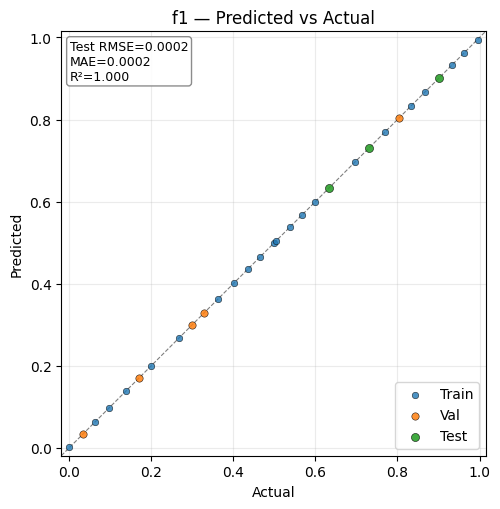

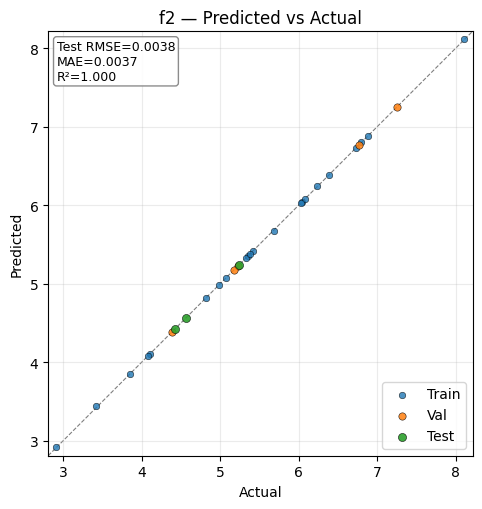

([<Figure size 560x520 with 1 Axes>, <Figure size 560x520 with 1 Axes>],
 [<Axes: title={'center': 'f1 — Predicted vs Actual'}, xlabel='Actual', ylabel='Predicted'>,
  <Axes: title={'center': 'f2 — Predicted vs Actual'}, xlabel='Actual', ylabel='Predicted'>],
 [{'target': 'f1',
   'RMSE': 0.00020416065436580985,
   'MAE': 0.00018012571061402452,
   'R2': 0.9999965710020225},
  {'target': 'f2',
   'RMSE': 0.0037754295565836627,
   'MAE': 0.0037375899272416766,
   'R2': 0.9998866441966445}])

In [26]:
plot_pred_vs_actual_from_auto(
    auto,
    #savepath_prefix="outputs_battery_gps_Li/pred_vs_actual"
)

In [28]:
refit_scope = "full"         # "train_val" | "full"
scaler_mode_final = "refit"  # 部署模型通常 refit 更稳（也可 frozen）

auto.finalize(
    X, Y,
    refit_scope=refit_scope,
    scaler_mode=scaler_mode_final,
    set_as_current=True,   # finalize 后让 predict() 默认使用最终模型
    verbose=True
)


[finalize] refit_scope=full, N=30, scaler_mode=refit, set_as_current=True


[MultiTaskGP(
   (likelihood): GaussianLikelihood(
     (noise_covar): HomoskedasticNoise(
       (noise_prior): LogNormalPrior()
       (raw_noise_constraint): GreaterThan(1.000E-04)
     )
   )
   (mean_module): ConstantMean()
   (covar_module): ScaleKernel(
     (base_kernel): RBFKernel(
       (lengthscale_prior): LogNormalPrior()
       (raw_lengthscale_constraint): GreaterThan(2.500E-02)
       (base_kernel): MaternKernel(
         (raw_lengthscale_constraint): GreaterThan(2.500E-02)
       )
     )
     (raw_outputscale_constraint): Positive()
   )
   (task_covar_module): IndexKernel(
     (raw_var_constraint): Positive()
   )
   (outcome_transform): Standardize()
 ),
 MultiTaskGP(
   (likelihood): GaussianLikelihood(
     (noise_covar): HomoskedasticNoise(
       (noise_prior): LogNormalPrior()
       (raw_noise_constraint): GreaterThan(1.000E-04)
     )
   )
   (mean_module): ConstantMean()
   (covar_module): ScaleKernel(
     (base_kernel): RBFKernel(
       (lengthscale_prio

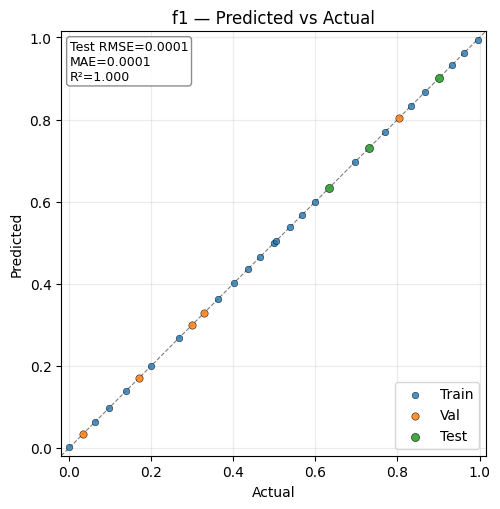

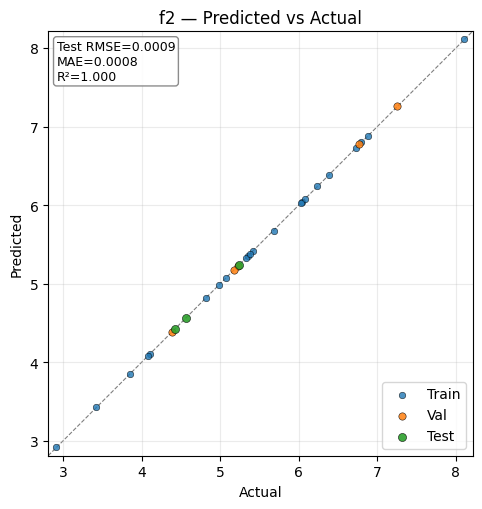

([<Figure size 560x520 with 1 Axes>, <Figure size 560x520 with 1 Axes>],
 [<Axes: title={'center': 'f1 — Predicted vs Actual'}, xlabel='Actual', ylabel='Predicted'>,
  <Axes: title={'center': 'f2 — Predicted vs Actual'}, xlabel='Actual', ylabel='Predicted'>],
 [{'target': 'f1',
   'RMSE': 0.00013713780629940998,
   'MAE': 0.00010792214210201638,
   'R2': 0.9999984528318122},
  {'target': 'f2',
   'RMSE': 0.0009103572664091355,
   'MAE': 0.0007988953862045159,
   'R2': 0.9999934092514559}])

In [29]:
plot_pred_vs_actual_from_auto(
    auto,
    # savepath_prefix="outputs_battery_gps_Li/pred_vs_actual"
)

In [37]:

calibrate_from_auto_test(auto, alpha=0.1, method="per_target")

x_min  = auto.x_min.detach().cpu().numpy()
x_span = auto.x_span.detach().cpu().numpy()

bounds = np.tile(np.array([0, 1.0]), (6, 1))

res = surrogate_pareto_front(
    auto,
    bounds,
    model_key="eval_models",
    sense=["min","min"],

    use_hull=False,
    hull_ref="all",

    use_calibration=True,
    calibrator=calibrate_for_auto,
    
    n_candidates=100000,
    sampler="sobol",
)

X_p = res.X_pareto
Y_p = res.Y_pareto

In [38]:
Y_p_true = benchmark_ZDT2(X_p)

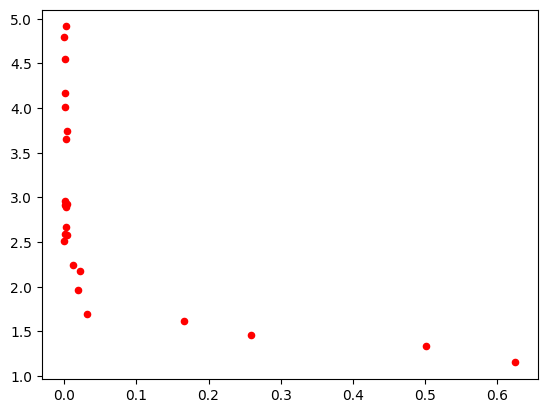

In [39]:
plt.scatter(Y_p_true[:,0], Y_p_true[:,1], c='red', s=20)

# 

# Validation

In [5]:
import numpy as np
import torch
from torch.quasirandom import SobolEngine

def sobol_in_box(n_dim, N, lb, ub, seed=0):
    eng = SobolEngine(dimension=n_dim, scramble=True, seed=seed)
    U = eng.draw(N).double().cpu().numpy()
    lb = np.asarray(lb, float); ub = np.asarray(ub, float)
    return lb + (ub - lb) * U

def f_gt(X):   # X: (N,d) numpy
    return benchmark_dtlz2(X)  # (N,M)

def sense_to_maximization(Y, sense):
    Y = np.asarray(Y, float)
    Ymax = Y.copy()
    for j, s in enumerate(sense):
        sj = str(s).strip().lower()
        if sj == "min":
            Ymax[:, j] = -Ymax[:, j]
        elif sj == "max":
            pass
        else:
            raise ValueError("sense must be 'min' or 'max'")
    return Ymax

import torch
from botorch.utils.multi_objective.pareto import is_non_dominated

def pareto_indices_botorch_max(Ymax: np.ndarray):
    Yt = torch.as_tensor(Ymax, dtype=torch.double)
    mask = is_non_dominated(Yt)  # assumes maximization :contentReference[oaicite:2]{index=2}
    idx = torch.where(mask)[0].cpu().numpy()
    return idx, mask.cpu().numpy()

def build_ground_truth_pf(lb, ub, d, sense, N_pool=20000, seed=0):
    X_pool = sobol_in_box(d, N_pool, lb, ub, seed=seed)
    Y_pool = f_gt(X_pool)
    Y_pool_max = sense_to_maximization(Y_pool, sense)
    idx_pf, mask = pareto_indices_botorch_max(Y_pool_max)
    X_pf = X_pool[idx_pf]
    Y_pf = Y_pool[idx_pf]
    return {
        "X_pool": X_pool,
        "Y_pool": Y_pool,
        "X_pf_gt": X_pf,
        "Y_pf_gt": Y_pf,
        "idx_pf_gt": idx_pf,
        "sense": sense,
    }


In [6]:
def to_max_space(Y, sense):
    return sense_to_maximization(Y, sense)

def pairwise_dist(A, B):
    # A: (n,a), B: (m,a)
    # return (n,m)
    A2 = np.sum(A*A, axis=1, keepdims=True)
    B2 = np.sum(B*B, axis=1, keepdims=True).T
    return np.sqrt(np.maximum(A2 + B2 - 2*A@B.T, 0.0))

def GD(Y_pred, Y_gt):
    D = pairwise_dist(Y_pred, Y_gt)
    return np.mean(np.min(D, axis=1))

def IGD(Y_pred, Y_gt):
    D = pairwise_dist(Y_gt, Y_pred)
    return np.mean(np.min(D, axis=1))

def hausdorff(Y_pred, Y_gt):
    D_pg = pairwise_dist(Y_pred, Y_gt)
    d1 = np.max(np.min(D_pg, axis=1))  # pred -> gt
    d2 = np.max(np.min(D_pg, axis=0))  # gt -> pred
    return max(d1, d2)

def pf_recall(Y_pred, Y_gt, eps):
    D = pairwise_dist(Y_gt, Y_pred)
    covered = (np.min(D, axis=1) <= eps)
    return float(np.mean(covered))

from botorch.utils.multi_objective.hypervolume import Hypervolume

def hypervolume_max(Ymax_pf, ref_point_max):
    Yt = torch.as_tensor(Ymax_pf, dtype=torch.double)
    ref = torch.as_tensor(ref_point_max, dtype=torch.double)
    hv = Hypervolume(ref_point=ref)  # maximization interface :contentReference[oaicite:4]{index=4}
    return float(hv.compute(Yt))

def choose_ref_point_max(Ymax_pool, margin=0.05):
    # ref = min - margin*(max-min)
    ymin = Ymax_pool.min(axis=0)
    ymax = Ymax_pool.max(axis=0)
    return ymin - margin*(ymax - ymin)


In [7]:
def make_auto(test_frac=0.1):
    cfg = AutoConfig(
        seed=7,
        test_frac=test_frac,
        val_frac=0.15,
        use_ks_for_test=False,
        bags=10,              # 测试用 2，正式再开 10
        device=device,
        dtype=dtype,
    )
    auto = AutoMultiOutputGP(
        feature_names=FEATURES,
        target_names=TARGETS,
        config=cfg,
    )
    return auto

In [8]:
import numpy as np

def gt_pf_dtlz2_with_X(d=6, n_pf=2000):
    """
    Construct Pareto-optimal X and Y for DTLZ2 with M=2.
    Domain: x in [0,1]^d.
    PF achieved by setting x2..xd = 0.5 (=> g=0), sweeping x1 in [0,1].
    """
    x1 = np.linspace(0.0, 1.0, n_pf)
    X_pf = np.full((n_pf, d), 0.5, dtype=float)
    X_pf[:, 0] = x1

    # DTLZ2 (M=2) objectives
    g = np.sum((X_pf[:, 1:] - 0.5)**2, axis=1)  # should be all zeros
    f1 = (1.0 + g) * np.cos(X_pf[:, 0] * np.pi/2)
    f2 = (1.0 + g) * np.sin(X_pf[:, 0] * np.pi/2)
    Y_pf = np.column_stack([f1, f2])

    return X_pf, Y_pf


In [9]:
import numpy as np
import torch
from torch.quasirandom import SobolEngine
from botorch.utils.multi_objective.pareto import is_non_dominated

def build_gt_dict(
    *,
    d,
    sense,
    lb,
    ub,
    N_pool=5000,
    seed=0,
):
    """
    Build ground-truth dictionary for benchmark.

    Returns gt_dict with keys:
      - X_pool, Y_pool
      - X_pf_gt, Y_pf_gt
      - sense
    """

    # ---- 1) Sobol pool in design space ----
    eng = SobolEngine(dimension=d, scramble=True, seed=seed)
    U = eng.draw(N_pool).double().cpu().numpy()
    lb = np.asarray(lb, float)
    ub = np.asarray(ub, float)
    X_pool = lb + (ub - lb) * U

    # ---- 2) Ground-truth evaluation ----
    Y_pool = f_gt(X_pool)          # (N_pool, M)

    # ---- 3) Convert to maximization space ----
    Y_pool_max = Y_pool.copy()
    for j, s in enumerate(sense):
        if s == "min":
            Y_pool_max[:, j] = -Y_pool_max[:, j]

    # ---- 4) Ground-truth Pareto front ----
    # Yt = torch.as_tensor(Y_pool_max, dtype=torch.double)
    # mask = is_non_dominated(Yt)
    # idx_pf = torch.where(mask)[0].cpu().numpy()


    # X_pf_gt = X_pool[idx_pf]
    # Y_pf_gt = Y_pool[idx_pf]

    X_pf_gt, Y_pf_gt = gt_pf_dtlz2_with_X(d)

    return {
        "X_pool": X_pool,
        "Y_pool": Y_pool,
        "X_pf_gt": X_pf_gt,
        "Y_pf_gt": Y_pf_gt,
        "sense": sense,
    }


In [10]:
import numpy as np

def evaluate_one_trial(
    make_auto,                 # <- 你的建模 factory：auto = make_auto()
    X_train, Y_train,
    gt_dict,
    *,
    pf_cfg,                    # <- surrogate_pareto_front 的设置（必传）
    calibration_cfg=None,      # <- dict: {"enabled":True, "alpha":0.1, "method":"per_target", "source":"test"}
    eps_ratio=0.01,
    verbose=False,
):
    sense   = gt_dict["sense"]
    Y_pf_gt = gt_dict["Y_pf_gt"]

    # 1) build + fit
    auto = make_auto()
    auto.fit(X_train, Y_train)
    # -------- 2) optional: final evaluation on held-out split inside auto --------
    if hasattr(auto, "evaluate_final"):
        _ = auto.evaluate_final(
            X_train, Y_train,
            final_eval_on=final_eval_on,
            scaler_mode=scaler_mode_eval,
            verbose=verbose,
        )

    # -------- 3) finalize (refit for deployment) --------
    if hasattr(auto, "finalize"):
        auto.finalize(
            X_train, Y_train,
            refit_scope=refit_scope,
            scaler_mode=scaler_mode_final,
            set_as_current=True,
            verbose=verbose,
        )

    # 2) calibration (可选)：用 auto 内部 test split 做
    # 你需要自己已有一个函数：calibrate_from_auto_test(auto, alpha, method, ...)
    if calibration_cfg and calibration_cfg.get("enabled", False):
        # source = calibration_cfg.get("source", "test")  # "test" | "train" | "val" | "train_val" | "all"
        alpha  = calibration_cfg.get("alpha", 0.10)
        method = calibration_cfg.get("method", "per_target")
        
        # calibrate_from_auto_test(auto, alpha, method)
        print("Calibrating")
        # calibrate_from_auto_test(auto, alpha=alpha, method=method)  # 你已有/我之前给过版本
        auto.calibration = calibrate_from_cv_plus_up(
            auto = auto,
            X=auto.X_all,
            Y=auto.Y_all,
            K=5,
            alpha=0.10,
            method="per_target",
            model_key="current",   # 或 "current"
            seed=7,
        )
        
        auto.finalize(
            X_train, Y_train,
            refit_scope=refit_scope,
            scaler_mode=scaler_mode_final,
            set_as_current=True,
            verbose=verbose,
        )
    # 3) bounds：默认从 auto 的 x_min/x_span 推断，也允许 pf_cfg 覆盖
    bounds = pf_cfg.get("bounds", None)

    if bounds is None:
        x_min  = auto.x_min.detach().cpu().numpy()
        x_span = auto.x_span.detach().cpu().numpy()
        bounds = np.column_stack([x_min, x_min + x_span])  # (d,2)

    # 4) surrogate PF（setting 全从 pf_cfg 输入）
    #    这里强制把 sense 用 gt_dict 的 sense（避免你忘了同步）
    # res = surrogate_pareto_front_nsga2(
    #     auto,
    #     # bounds,
    #     **{**pf_cfg, "bounds": bounds, "sense": sense},
    # )

    res = surrogate_pareto_front_nsga2(
        auto,
        bounds=pf_cfg["bounds"],
        pop_size=256,
        n_gen=100,
        seed=pf_cfg.get("seed", 0),
        model_key=pf_cfg.get("model_key", "final_models"),
        sense=pf_cfg.get("sense", ["min","min"]),
        use_calibration=pf_cfg.get("use_calibration", True),
        calibrator=pf_cfg.get("calibrator", calibrate_for_auto),
        use_hull=pf_cfg.get("use_hull", False),
        hull_ref=pf_cfg.get("hull_ref", "train_val"),
    )

    # 5) PF_pred：surrogate 已经返回 Pareto set（真值目标）
    X_pf_pred = res.X_pareto
    Y_pf_pred_or = res.Y_pareto
    Y_pf_pred = f_gt(X_pf_pred)          # (Np, M) -- 你确认这是“真值目标”时才这样用

    # 6) 指标统一在 max-space 计算
    Y_pf_pred_max = to_max_space(Y_pf_pred, sense)
    Y_pf_gt_max   = to_max_space(Y_pf_gt, sense)


    rng = Y_pf_gt_max.max(axis=0) - Y_pf_gt_max.min(axis=0)
    eps = eps_ratio * float(np.linalg.norm(rng) + 1e-12)

    out = {
        "GD": GD(Y_pf_pred_max, Y_pf_gt_max),
        "IGD": IGD(Y_pf_pred_max, Y_pf_gt_max),
        "Hausdorff": hausdorff(Y_pf_pred_max, Y_pf_gt_max),
        "Recall": pf_recall(Y_pf_pred_max, Y_pf_gt_max, eps=eps),
    }

    # HV
    Y_pool_max = to_max_space(gt_dict["Y_pool"], sense)
    ref = choose_ref_point_max(Y_pool_max, margin=0.05)
    out["HV_pred"]  = hypervolume_max(Y_pf_pred_max, ref)
    out["HV_gt"]    = hypervolume_max(Y_pf_gt_max, ref)
    out["HV_ratio"] = out["HV_pred"] / (out["HV_gt"] + 1e-12)

    # out["n_pf_pred"] = int(len(idx_pf_pred))
    out["n_pf_gt"]   = int(len(gt_dict["Y_pf_gt"]))
    out["n_pareto_x"] = int(len(X_pf_pred))
    out['pareto_X'] = X_pf_pred
    out['pareto_Y'] = Y_pf_pred_or

    return out, auto


## single test

In [11]:
d = 6
sense = ["min", "min"]

lb = np.zeros(d)
ub = np.ones(d)

gt_dict = build_gt_dict(
    d=d,
    sense=sense,
    lb=lb,
    ub=ub,
    N_pool=30000,   # test 阶段先小
    seed=0,
)

In [ ]:
rng = np.random.default_rng(0)

X_pool = gt_dict["X_pool"]
Y_pool = gt_dict["Y_pool"]

idx = rng.choice(len(X_pool), size=60, replace=False)
X_train = X_pool[idx]
Y_train = Y_pool[idx]
print("Train shape:", X_train.shape, Y_train.shape)

flag_calibration = True

pf_cfg = dict(
    sense=['min','min'],
    use_hull=False,
    hull_ref="train_val",
    use_calibration=flag_calibration,     # 第一次先关掉 calibration，减少变量
    calibrator=calibrate_for_auto,
    sampler="sobol",
    n_candidates=100000,         # 测试先小一点
    model_key="final_models",
    bounds=np.tile(np.array([0, 1.0]), (d, 1)),               # 用 auto 的 x_min/x_span 自动推断
)

calibration_cfg = {
    "enabled": flag_calibration,
    "alpha": 0.1,
    "method": "per_target",
    # "source": "test",
}

final_eval_on = "test"     # "train" | "train_val" | "test" | "all"
scaler_mode_eval = "frozen"  # 推荐 frozen（口径与选参一致）
refit_scope = "full"         # "train_val" | "full"
scaler_mode_final = "frozen"  # 部署模型通常 refit 更稳（也可 frozen）

out, auto_cal_new = evaluate_one_trial(
    make_auto=make_auto,
    X_train=X_train,
    Y_train=Y_train,
    gt_dict=gt_dict,
    pf_cfg=pf_cfg,
    calibration_cfg=calibration_cfg,      # 先不校准
    eps_ratio=0.01,
    verbose=True,
)

print("=== One-trial result ===")
for k, v in out.items():
    if k in ("pareto_X", "pareto_Y"):
        continue
    print(f"{k:15s}: {v}")


Train shape: (60, 6) (60, 2)
Split sizes -> train: 45, val: 9, test: 6 (KS_test=False)
[ICM] RBF        | val-score=0.076301 | per-target RMSE=[0.0952 0.0574]
[ICM] Matern(0.5) | val-score=0.076293 | per-target RMSE=[0.0952 0.0574]
[ICM] Matern(1.5) | val-score=0.076293 | per-target RMSE=[0.0952 0.0574]
[ICM] Matern(2.5) | val-score=0.076283 | per-target RMSE=[0.0952 0.0574]
[IND:t0] RBF        | RMSE=0.126031
[IND:t0] Matern(0.5) | RMSE=0.122239
[IND:t0] Matern(1.5) | RMSE=0.107283
[IND:t0] Matern(2.5) | RMSE=0.117887
[IND:t1] RBF        | RMSE=0.091073
[IND:t1] Matern(0.5) | RMSE=0.085238
[IND:t1] Matern(1.5) | RMSE=0.100102
[IND:t1] Matern(2.5) | RMSE=0.100424
[IND] per-target best kernels -> [('Matern', 1.5), ('Matern', 0.5)]
[IND] overall val-score=0.096260 | per-target RMSE=[0.1073 0.0852]

==> Chosen family: ICM, kernel: Matern(2.5), val-score=0.076283
[evaluate_final] fit_on=54, eval_on=6, mode=test, scaler_mode=frozen
{'split': 'eval:test', 'f1_RMSE': 0.08231149356819596, 'f1_

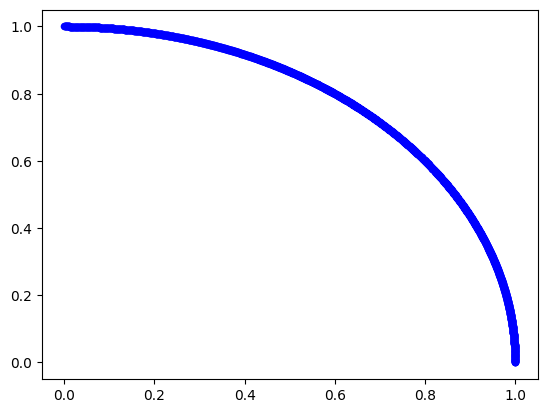

In [25]:
plt.scatter((gt_dict['Y_pf_gt'])[:,0], (gt_dict['Y_pf_gt'])[:,1], c='blue', s=20)

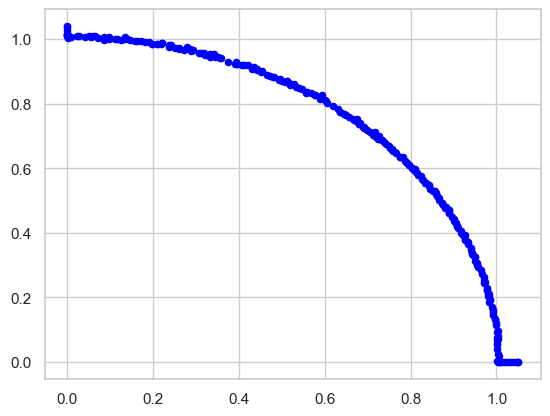

In [58]:
plt.scatter(benchmark_dtlz2(out['pareto_X'])[:,0], benchmark_dtlz2(out['pareto_X'])[:,1], c='blue', s=20)

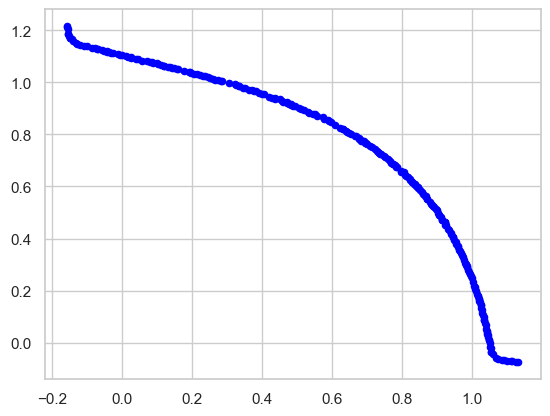

In [59]:
plt.scatter((out['pareto_Y'])[:,0], (out['pareto_Y'])[:,1], c='blue', s=20)

In [15]:
import copy

In [13]:
def calibrate_from_cv_plus_up(
    auto,                   # factory: make_auto() -> fresh auto
    X: np.ndarray,
    Y: np.ndarray,
    *,
    K: int = 5,
    alpha: float = 0.10,
    method: str = "per_target",   # "per_target" | "joint"
    eps: float = 1e-12,
    model_key: str = "final_models",   # which models inside each fold-auto to use
    seed: int = 0,
    batch_size: int = 4096,
):
    """
    CV+ / cross-fitted conformal calibration.

    Returns a calibration dict compatible with auto.calibration.
    """

    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X must be (N,d), Y must be (N,M)")

    N, M = Y.shape
    if N < K:
        raise ValueError(f"N={N} must be >= K={K}")

    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    folds = np.array_split(perm, K)

    Z_all = []   # standardized residuals from all folds

    for k in range(K):
        idx_te = folds[k]
        idx_tr = np.concatenate([folds[i] for i in range(K) if i != k])

        auto_k = copy.deepcopy(auto)
        # auto_k.fit(X[idx_tr], Y[idx_tr])
        # auto_k.eval()
        # auto_k.finalize(
        #     X[idx_tr], Y[idx_tr], refit_scope="full", scaler_mode = "refit"
        # )
        auto_k.final_models = auto_k._train_models_on(X[idx_tr], Y[idx_tr], scaler_mode="frozen")

        with torch.inference_mode():
            MU, SIG = auto_k.predict(
                X[idx_te],
                model_key=model_key,
                batch_size=batch_size,
            )

        MU = np.asarray(MU, float)
        SIG = np.asarray(SIG, float)
        Yk  = Y[idx_te]

        Zk = np.abs(Yk - MU) / (SIG + eps)   # (n_k, M)
        Z_all.append(Zk)

    Z = np.vstack(Z_all)   # (N, M)  ← out-of-fold residuals

    # ---- conformal quantile ----
    method = method.lower()
    if method == "per_target":
        alpha_j = alpha / M
        q_vec = np.quantile(Z, 1.0 - alpha_j, axis=0)
    elif method == "joint":
        alpha_j = alpha
        s = np.max(Z, axis=1)   # (N,)
        q = float(np.quantile(s, 1.0 - alpha))
        q_vec = np.full(M, q, dtype=float)
    else:
        raise ValueError("method must be 'per_target' or 'joint'")

    return {
        "enabled": True,
        "method": method,
        "alpha": float(alpha),
        "alpha_j": float(alpha_j),
        "q_vec": np.asarray(q_vec, float),
        "source": "cv+",
        "K": int(K),
        "n_cal": int(N),
        "seed": int(seed),
        "model_key": model_key,
    }


## calibration test

In [18]:
import numpy as np

def empirical_coverage(y_true, mean, std, q):
    """
    y_true, mean, std: (N, M)
    q: scalar or (M,)
    """
    lo = mean - q * std
    hi = mean + q * std
    covered = (y_true >= lo) & (y_true <= hi)
    return covered.mean(axis=0)  # per target

def reliability_curve(y_true, mean, std, q_grid):
    """
    q_grid: list of quantiles, e.g. [0.5, 1.0, 1.5, 2.0]
    """
    covs = []
    for q in q_grid:
        cov = empirical_coverage(y_true, mean, std, q)
        covs.append(cov)
    return np.stack(covs)  # (len(q_grid), M)

def calibration_ece(y_true, mean, std, q, alpha):
    cov = empirical_coverage(y_true, mean, std, q)
    return np.mean(np.abs(cov - (1 - alpha)))

def evaluate_calibration(auto, X_cal, Y_cal, alpha=0.1):
    mean, std = auto.predict(X_cal)

    q = auto.calibration["q_vec"] if hasattr(auto, "calibration") else 1.0

    out = {
        "coverage": empirical_coverage(Y_cal, mean, std, q),
        "ece": calibration_ece(Y_cal, mean, std, q, alpha),
    }
    return out


In [19]:
lb, ub = 0, 1                 # 变量范围
eng = SobolEngine(dimension=n, scramble=True, seed=7)
U = eng.draw(10000).numpy()
X_eval = lb + (ub - lb) * U
np.random.seed(7)
# noise = np.random.normal(0.0, 0.1, size=(N,2))
Y_eval = benchmark_dtlz2(X_eval) # + noise

In [20]:
# cal_uncal = evaluate_calibration(auto_nocal, X_eval, Y_eval)
# cal_cal   = evaluate_calibration(auto_cal,   X_eval, Y_eval)
cal_cal_new   = evaluate_calibration(auto_cal_new,   X_eval, Y_eval)
print("=== Calibration evaluation ===")
# print("Uncalibrated coverage:", cal_uncal["coverage"], "ECE:", cal_uncal["ece"])
# print("Calibrated coverage:  ", cal_cal["coverage"],   "ECE:", cal_cal["ece"])
print("Calibrated(CV+) coverage:  ", cal_cal_new["coverage"],   "ECE:", cal_cal_new["ece"])


=== Calibration evaluation ===
Calibrated(CV+) coverage:   [0.6053 0.6059] ECE: 0.29440000000000005


## run benchmark

In [12]:
def run_benchmark_seeds(
    *,
    gt_dict,
    make_auto,
    pf_cfg,
    calibration_cfg=None,
    n_train: int = 30,
    seeds=range(10),
    eps_ratio: float = 0.01,
    verbose: bool = False,
):
    """
    Run benchmark by varying random seeds only (single design).

    Parameters
    ----------
    gt_dict : dict
        Must contain X_pool, Y_pool, Y_pf_gt, sense
    make_auto : callable
        Factory returning a fresh auto model
    pf_cfg : dict
        surrogate_pareto_front configuration
    calibration_cfg : dict or None
        Calibration configuration (or None to disable)
    n_train : int
        Number of training samples per seed
    seeds : iterable
        Random seeds controlling training set selection
    eps_ratio : float
        Recall epsilon scaling
    verbose : bool

    Returns
    -------
    df_all : pd.DataFrame
        One row per seed with all metrics
    summary : pd.Series
        Mean / std across seeds
    """

    X_pool = np.asarray(gt_dict["X_pool"])
    Y_pool = np.asarray(gt_dict["Y_pool"])
    N_pool = X_pool.shape[0]

    rows = []

    for seed in seeds:
        rng = np.random.default_rng(int(seed))
        idx = rng.choice(N_pool, size=n_train, replace=False)

        X_train = X_pool[idx]
        Y_train = Y_pool[idx]

        out = evaluate_one_trial(
            make_auto=make_auto,
            X_train=X_train,
            Y_train=Y_train,
            gt_dict=gt_dict,
            pf_cfg=pf_cfg,
            calibration_cfg=calibration_cfg,
            eps_ratio=eps_ratio,
            verbose=verbose,
        )

        out["seed"] = int(seed)
        out["n_train"] = int(n_train)
        rows.append(out)

    df_all = pd.DataFrame(rows)

    # 你关心的核心指标
    metric_cols = [
        c for c in
        ["GD", "IGD", "Hausdorff", "Recall", "HV_ratio", "HV_pred", "HV_gt",
         "n_pf_pred", "n_pf_gt", "n_pareto_x"]
        if c in df_all.columns
    ]

    # summary = df_all[metric_cols].agg(["mean", "std", "median", "min", "max"])
    summary = df_all[metric_cols].agg(
    ["mean", "std", "median", "min", "max",
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
    )

    # 给 lambda 行改个好名字
    summary.index = ["mean", "std", "median", "min", "max", "q25", "q75"]

    return df_all, summary


In [ ]:
d = 6
sense = ["min", "min"]

lb = np.zeros(d)
ub = np.ones(d)

gt_dict = build_gt_dict(
    d=d,
    sense=sense,
    lb=lb,
    ub=ub,
    N_pool=30000,   # test 阶段先小
    seed=0,
)

In [78]:
device = torch.device("cpu") #"cuda" if torch.cuda.is_available() else 
dtype  = torch.double

X_pool = gt_dict["X_pool"]
Y_pool = gt_dict["Y_pool"]

flag_calibration = True

pf_cfg = dict(
    sense=['min','min'],
    use_hull=False,
    hull_ref="all",
    use_calibration=flag_calibration,     # 第一次先关掉 calibration，减少变量
    calibrator=calibrate_for_auto,
    sampler="sobol",
    n_candidates=100000,         # 测试先小一点
    model_key="final_models",
    bounds = np.tile(np.array([0.0, 1.0]), (d, 1))
)

calibration_cfg = {
    "enabled": flag_calibration,
    "alpha": 0.1,
    "method": "per_target",
    # "source": "test",
}

final_eval_on = "test"     # "train" | "train_val" | "test" | "all"
scaler_mode_eval = "frozen"  # 推荐 frozen（口径与选参一致）
refit_scope = "full"         # "train_val" | "full"
scaler_mode_final = "refit"  # 部署模型通常 refit 更稳（也可 frozen）

df_all, summary = run_benchmark_seeds(
    gt_dict=gt_dict,
    make_auto=make_auto,
    pf_cfg=pf_cfg,
    calibration_cfg=calibration_cfg,
    n_train=70,
    seeds=range(20),
    eps_ratio=0.01,
    verbose=False,
)

Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(0.5) | val-score=0.055297 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(1.5) | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(2.5) | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[IND:t0] RBF        | RMSE=0.060043
[IND:t0] Matern(0.5) | RMSE=0.072501
[IND:t0] Matern(1.5) | RMSE=0.045330
[IND:t0] Matern(2.5) | RMSE=0.044755
[IND:t1] RBF        | RMSE=0.112133
[IND:t1] Matern(0.5) | RMSE=0.103309
[IND:t1] Matern(1.5) | RMSE=0.104263
[IND:t1] Matern(2.5) | RMSE=0.104049
[IND] per-target best kernels -> [('Matern', 2.5), ('Matern', 0.5)]
[IND] overall val-score=0.074032 | per-target RMSE=[0.0448 0.1033]

==> Chosen family: ICM, kernel: Matern(1.5), val-score=0.055296
Calibrating
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.104201 | per-target RMSE=[0.1041 0.1043]
[ICM] Matern(

In [79]:
summary

,GD,IGD,Hausdorff,Recall,HV_ratio,HV_pred,HV_gt,n_pf_gt,n_pareto_x
mean,0.016362,0.014759,0.070247,0.702075,0.993638,3.740604,3.764555e+00,2000.0,256.0
std,0.013780,0.012027,0.049958,0.300638,0.005136,0.019336,4.556259e-16,0.0,0.0
median,0.013336,0.009618,0.055337,0.840750,0.995530,3.747729,3.764555e+00,2000.0,256.0
min,0.001989,0.002744,0.021109,0.000000,0.977464,3.679717,3.764555e+00,2000.0,256.0
max,0.063320,0.050966,0.183237,1.000000,0.998924,3.760503,3.764555e+00,2000.0,256.0
q25,0.007295,0.006910,0.033594,0.520625,0.992007,3.734466,3.764555e+00,2000.0,256.0
q75,0.022218,0.018934,0.076339,0.987375,0.996927,3.752987,3.764555e+00,2000.0,256.0


In [80]:
out_path = "normal_cali_results.csv"
df_all.to_csv(out_path, index=False)

## Draw

In [1]:
import pandas as pd
import os

# 你的文件名 -> 方法名（显示在图上的）
files = {
    "DTLZ2/basic_results.csv": "A (raw)",
    "DTLZ2/normal_cali_results.csv": "B (calib)",
    "DTLZ2/cv+_results.csv": "C (CV+)",
}

# data_dir = r"."   # 改成你的目录，比如 r"C:\Users\...\your_folder"

dfs = []
for fname, method in files.items():
    # fpath = os.path.join(data_dir, fname)
    df = pd.read_csv(fname)
    df["Method"] = method
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(df_all.shape)
print(df_all.columns)
df_all.head()


(60, 14)
Index(['GD', 'IGD', 'Hausdorff', 'Recall', 'HV_pred', 'HV_gt', 'HV_ratio',
       'n_pf_gt', 'n_pareto_x', 'pareto_X', 'pareto_Y', 'seed', 'n_train',
       'Method'],
      dtype='object')


,GD,IGD,Hausdorff,Recall,HV_pred,HV_gt,HV_ratio,n_pf_gt,n_pareto_x,pareto_X,pareto_Y,seed,n_train,Method
0,0.006713,0.006402,0.031714,0.9025,3.755009,3.764555,0.997464,2000,256,[[9.99736590e-01 5.31167400e-01 3.90960779e-01...,[[-1.71248559e-01 1.30989148e+00]\n [-1.70698...,0,70,A (raw)
1,0.004089,0.003966,0.049560,1.0000,3.758627,3.764555,0.998425,2000,256,[[9.99963638e-01 4.93449961e-01 5.28546850e-01...,[[-7.03409227e-02 1.09097528e+00]\n [-6.92587...,1,70,A (raw)
2,0.046910,0.037079,0.440592,0.3340,3.720929,3.764555,0.988411,2000,256,[[9.99674732e-01 5.41656395e-01 3.67578044e-01...,[[ 0.05992805 1.23305773]\n [ 0.06044996 1.2...,2,70,A (raw)
3,0.015030,0.017359,0.181584,0.7875,3.747982,3.764555,0.995598,2000,256,[[0.99997158 0.46865647 0.47735051 0.50369295 ...,[[-0.12354683 1.24525992]\n [-0.12258543 1.2...,3,70,A (raw)
4,0.005008,0.004884,0.025203,1.0000,3.756836,3.764555,0.997949,2000,256,[[9.99979133e-01 4.99840750e-01 3.74966185e-01...,[[-4.04807475e-02 1.20324105e+00]\n [-3.88420...,4,70,A (raw)


In [2]:
metrics = ["GD", "IGD", "Hausdorff", "Recall", "HV_ratio"]

# 只保留 Method + metrics（避免杂列影响）
keep_cols = ["Method"] + [c for c in metrics if c in df_all.columns]
df_plot = df_all[keep_cols].copy()

df_long = df_plot.melt(id_vars="Method", var_name="Metric", value_name="Value")
df_long.head()


,Method,Metric,Value
0,A (raw),GD,0.006713
1,A (raw),GD,0.004089
2,A (raw),GD,0.046910
3,A (raw),GD,0.015030
4,A (raw),GD,0.005008


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

def violin_with_density_points(
    df_all,
    metric,
    method_order=None,
    palette="tab10",
):
    plt.figure(figsize=(8, 4))

    # 1) 透明 violin（只表示分布）
    sns.violinplot(
        data=df_all,
        x="Method",
        y=metric,
        order=method_order,
        palette=palette,
        cut=0,
        inner="quartile",        # 不画 box
        linewidth=1,
        alpha=0.35         # 透明！
    )

    # 2) 中间点：表示 density（每个点一个 seed）
    sns.stripplot(
        data=df_all,
        x="Method",
        y=metric,
        order=method_order,
        palette=palette,
        dodge=False,
        jitter=0.1,       # 横向轻微抖动 → 密度可视
        size=4,
        alpha=0.8,
        edgecolor="k",
        linewidth=0.3
    )

    plt.title(metric)
    # plt.tight_layout()
    plt.grid(False)
    plt.show()


C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


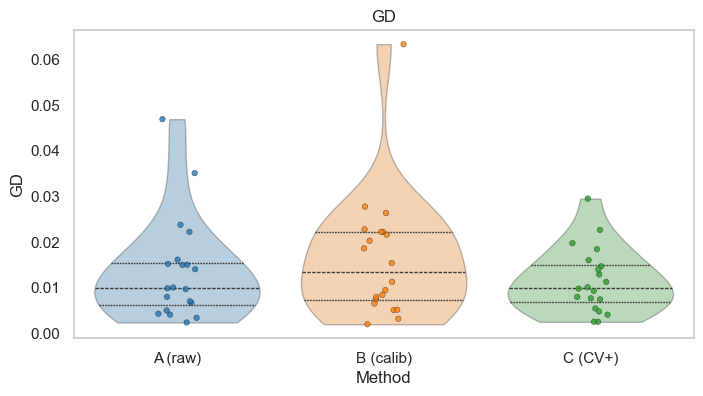

C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


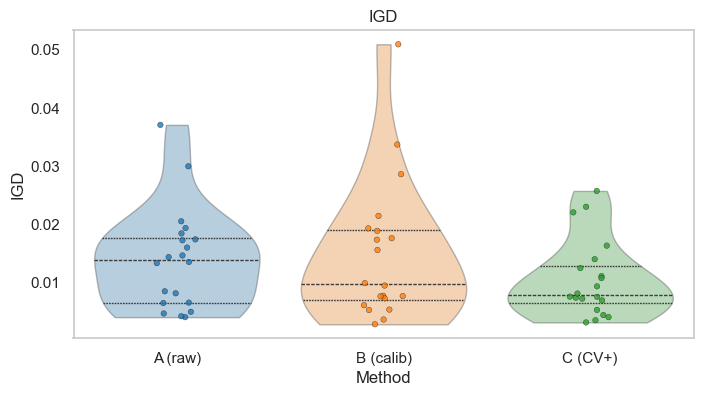

C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


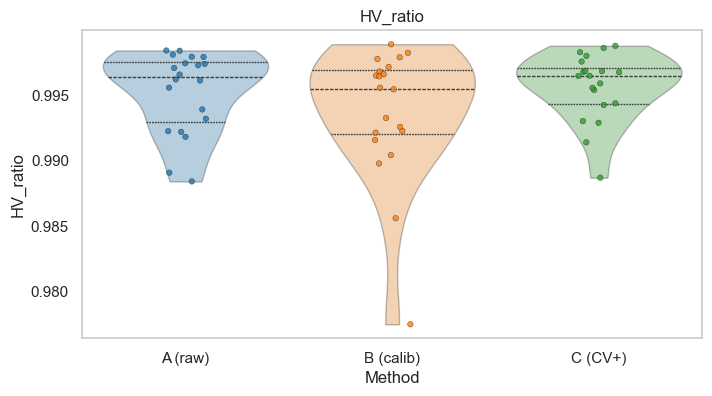

C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\n12046299\AppData\Local\Temp\ipykernel_24088\784055066.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


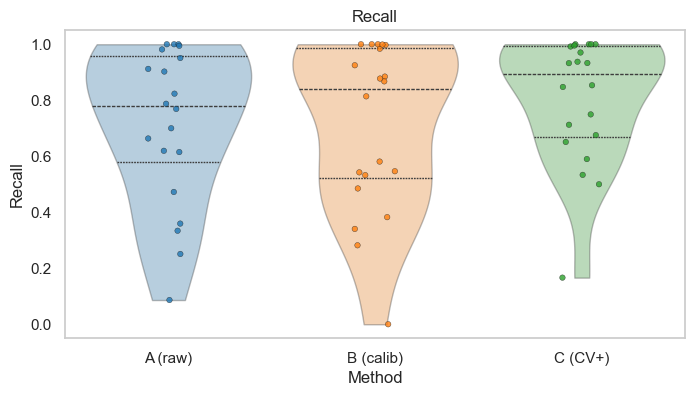

In [4]:
order = ["A (raw)", "B (calib)", "C (CV+)"]
violin_with_density_points(df_all, "GD", order)
violin_with_density_points(df_all, "IGD", order)
violin_with_density_points(df_all, "HV_ratio", order)
violin_with_density_points(df_all, "Recall", order)


## calibration coverage vs HV

In [21]:
import copy
import numpy as np
import matplotlib.pyplot as plt

def coverage_vs_HV(
    auto,
    q_vec_list=None,
    lambdas=None,
    *,
    base_q_vec=None,
    X_eval=None,
    Y_eval=None,
    gt_dict=None,
    pf_cfg=None,
    alpha=0.10,
    eps_ratio=0.01,
    verbose=False,
):
    """
    Sweep calibration q_vec (or scaling factors lambda) and evaluate:
      - calibration: coverage (per-target + mean), ECE
      - decision: HV_ratio (+ optional GD/IGD/Recall/Hausdorff)

    Parameters
    ----------
    auto : trained surrogate object with .predict(...) and .calibration field
    q_vec_list : list[np.ndarray], each (M,)
        Direct list of q vectors to try.
    lambdas : list[float], optional
        If provided, we will form q_vec = lambda * base_q_vec for each lambda.
    base_q_vec : np.ndarray, shape (M,), required if lambdas is not None
    X_eval, Y_eval : arrays for independent calibration evaluation
    gt_dict : dict with keys: "sense", "Y_pf_gt", "Y_pool"
    pf_cfg : dict for surrogate_pareto_front_nsga2 (must include bounds)
    alpha : float, nominal miscoverage (0.1 -> 90% intervals)
    eps_ratio : float for pf_recall tolerance
    """

    assert X_eval is not None and Y_eval is not None
    assert gt_dict is not None and pf_cfg is not None

    sense   = gt_dict["sense"]
    Y_pf_gt = gt_dict["Y_pf_gt"]

    # ---------- build q_vec_list from lambdas if requested ----------
    if lambdas is not None:
        if base_q_vec is None:
            raise ValueError("base_q_vec must be provided when lambdas is not None.")
        base_q_vec = np.asarray(base_q_vec, float)
        q_vec_list = [float(lam) * base_q_vec for lam in lambdas]
        x_axis = np.asarray(lambdas, float)
        x_label = r"scaling $\lambda$ (q = $\lambda q_0$)"
    else:
        if q_vec_list is None or len(q_vec_list) == 0:
            raise ValueError("Provide either q_vec_list or lambdas+base_q_vec.")
        q_vec_list = [np.asarray(q, float) for q in q_vec_list]
        x_axis = np.arange(len(q_vec_list), dtype=float)
        x_label = "q index"

    # ---------- helper: set/restore calibration safely ----------
    old_calibration = copy.deepcopy(getattr(auto, "calibration", None))

    rows = []
    for i, q_vec in enumerate(q_vec_list):
        q_vec = np.asarray(q_vec, float).reshape(-1)  # (M,)
        M = q_vec.shape[0]

        # Bonferroni alpha_j if you want "all objectives covered" guarantee
        alpha_j = alpha / M

        # temporarily set calibration
        auto.calibration = {
            "enabled": True,
            "method": "per_target",
            "alpha": float(alpha),
            "alpha_j": float(alpha_j),
            "q_vec": q_vec.copy(),
            "source": "sweep",
        }

        # ---- (1) Calibration metrics on independent eval set ----
        cal_res = evaluate_calibration(auto, X_eval, Y_eval, alpha=alpha)
        cov_vec = np.asarray(cal_res["coverage"], float).reshape(-1)  # (M,)
        cov_mean = float(np.mean(cov_vec))
        ece = float(cal_res["ece"])

        # ---- (2) PF + decision metrics ----
        # IMPORTANT: run PF inside the loop (you had it outside)
        res = surrogate_pareto_front_nsga2(
            auto,
            bounds=pf_cfg["bounds"],
            pop_size=pf_cfg.get("pop_size", 256),
            n_gen=pf_cfg.get("n_gen", 100),
            seed=pf_cfg.get("seed", 0),
            model_key=pf_cfg.get("model_key", "final_models"),
            sense=pf_cfg.get("sense", sense),
            use_calibration=True,  # force using auto.calibration (we are sweeping it)
            calibrator=pf_cfg.get("calibrator", None),
            use_hull=pf_cfg.get("use_hull", False),
            hull_ref=pf_cfg.get("hull_ref", "train_val"),
        )

        X_pf_pred = res.X_pareto
        # If you want to evaluate PF quality in true objectives:
        Y_pf_pred = f_gt(X_pf_pred)

        Y_pf_pred_max = to_max_space(Y_pf_pred, sense)
        Y_pf_gt_max   = to_max_space(Y_pf_gt, sense)

        # tolerance for recall
        rng = Y_pf_gt_max.max(axis=0) - Y_pf_gt_max.min(axis=0)
        eps = eps_ratio * float(np.linalg.norm(rng) + 1e-12)

        # HV ratio
        Y_pool_max = to_max_space(gt_dict["Y_pool"], sense)
        ref = choose_ref_point_max(Y_pool_max, margin=0.05)

        HV_pred  = float(hypervolume_max(Y_pf_pred_max, ref))
        HV_gt    = float(hypervolume_max(Y_pf_gt_max, ref))
        HV_ratio = HV_pred / (HV_gt + 1e-12)

        # Optional PF distance metrics
        gd  = float(GD(Y_pf_pred_max, Y_pf_gt_max))
        igd = float(IGD(Y_pf_pred_max, Y_pf_gt_max))
        hdf = float(hausdorff(Y_pf_pred_max, Y_pf_gt_max))
        rec = float(pf_recall(Y_pf_pred_max, Y_pf_gt_max, eps=eps))

        row = {
            "i": int(i),
            "x": float(x_axis[i]),
            "q_vec": q_vec,
            "q_mean": float(np.mean(q_vec)),
            "q_min": float(np.min(q_vec)),
            "q_max": float(np.max(q_vec)),
            "coverage_mean": cov_mean,
            "coverage_vec": cov_vec,
            "ece": ece,
            "HV_ratio": HV_ratio,
            "HV_pred": HV_pred,
            "HV_gt": HV_gt,
            "GD": gd,
            "IGD": igd,
            "Hausdorff": hdf,
            "Recall": rec,
            "n_pareto": int(len(X_pf_pred)),
        }
        rows.append(row)

        if verbose:
            print(f"[{i}] x={row['x']:.3g} q_mean={row['q_mean']:.3g} "
                  f"cov={row['coverage_mean']:.3f} ece={row['ece']:.3f} HVr={row['HV_ratio']:.3f}")

    # restore original calibration
    auto.calibration = old_calibration

    # ---------- Make arrays for plotting ----------
    xs = np.array([r["x"] for r in rows], float)
    cov = np.array([r["coverage_mean"] for r in rows], float)
    ece = np.array([r["ece"] for r in rows], float)
    hvr = np.array([r["HV_ratio"] for r in rows], float)

    # ---------- Plot 1: HV_ratio vs Coverage ----------
    plt.figure()
    plt.plot(cov, hvr, marker="o")
    plt.xlabel("Empirical coverage (mean over objectives)")
    plt.ylabel("HV ratio (pred / gt)")
    plt.title("Trade-off: calibration coverage vs Pareto quality")
    plt.grid(True)

    # ---------- Plot 2: Coverage & HV_ratio vs x (lambda or index) ----------
    plt.figure()
    plt.plot(xs, cov, marker="o", label="Coverage (mean)")
    plt.plot(xs, hvr, marker="o", label="HV ratio")
    plt.xlabel(x_label)
    plt.ylabel("Metric value")
    plt.title("Effect of q scaling on coverage and HV ratio")
    plt.legend()
    plt.grid(True)

    # ---------- Plot 3 (optional): ECE vs x ----------
    plt.figure()
    plt.plot(xs, ece, marker="o")
    plt.xlabel(x_label)
    plt.ylabel("ECE")
    plt.title("Effect of q scaling on ECE")
    plt.grid(True)

    plt.show()

    return rows


In [26]:
auto_cal_new.calibration

{'enabled': True,
 'method': 'per_target',
 'alpha': 0.1,
 'alpha_j': 0.05,
 'q_vec': array([0.59472304, 0.74456657]),
 'source': 'cv+',
 'K': 5,
 'n_cal': 60,
 'seed': 7,
 'model_key': 'current'}

[0] x=0 q_mean=0.2 cov=0.205 ece=0.695 HVr=0.997
[1] x=1 q_mean=0.5 cov=0.479 ece=0.421 HVr=0.996
[2] x=2 q_mean=0.67 cov=0.606 ece=0.294 HVr=0.996
[3] x=3 q_mean=0.8 cov=0.691 ece=0.209 HVr=0.995


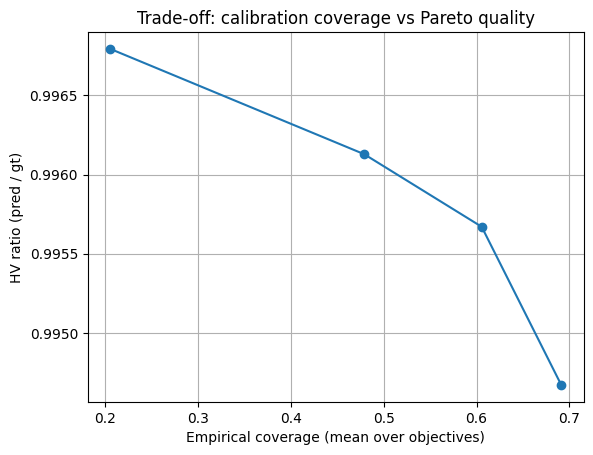

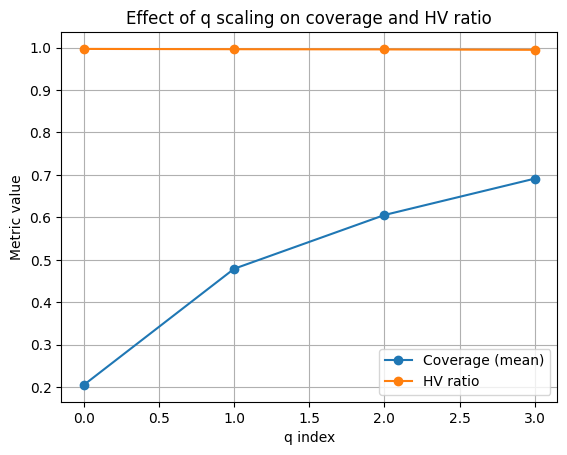

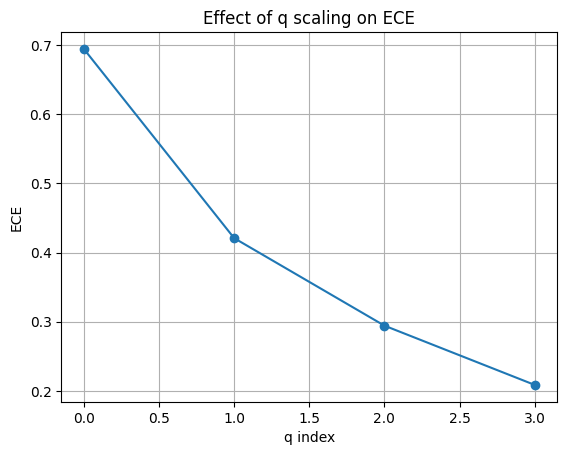

In [28]:
q_vec_list = [
    np.array([0.2, 0.2]),
    np.array([0.5, 0.5]),
    np.array([0.59472304, 0.74456657]),
    np.array([0.8, 0.8]),
    # np.array([1.0, 1.0]),
    # np.array([1.2, 1.2]),
    # np.array([1.5, 1.5]),
]
rows = coverage_vs_HV(
    auto_cal_new,
    q_vec_list=q_vec_list,
    X_eval=X_eval, Y_eval=Y_eval,
    gt_dict=gt_dict,
    pf_cfg=pf_cfg,
    alpha=0.1,
    verbose=True,
)


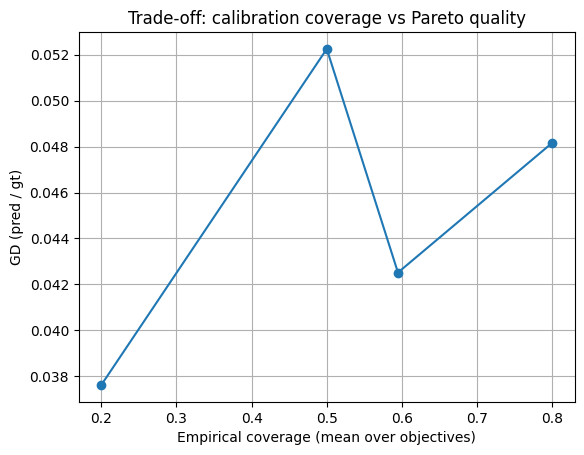

In [38]:
xs = np.array([r["q_min"] for r in rows], float)
cov = np.array([r["coverage_mean"] for r in rows], float)
ece = np.array([r["ece"] for r in rows], float)
hvr = np.array([r["Hausdorff"] for r in rows], float)

plt.figure()
plt.plot(xs, hvr, marker="o")
plt.xlabel("Empirical coverage (mean over objectives)")
plt.ylabel("GD (pred / gt)")
plt.title("Trade-off: calibration coverage vs Pareto quality")
plt.grid(True)

In [45]:
def set_global_seed(seed: int):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def run_one_seed(
    seed,
    *,
    make_auto,
    X_train, Y_train,
    X_eval, Y_eval,
    gt_dict,
    pf_cfg,
    alpha=0.1,
    lambdas=(0.4, 0.6, 0.8, 1.0, 1.2),
    verbose=False,
):
    set_global_seed(seed)

    auto = make_auto()
    auto.fit(X_train, Y_train)
    auto.finalize(X_train, Y_train, set_as_current=True)

    cal = calibrate_from_cv_plus_up(
        auto, X=X_train, Y=Y_train,
        K=5, alpha=alpha,
        method="per_target",
        model_key="final_models",
        seed=seed,
    )
    q_base = np.asarray(cal["q_vec"], float)

    # full sweep
    rows = coverage_vs_HV(
        auto,
        lambdas=list(lambdas),
        base_q_vec=q_base,
        X_eval=X_eval, Y_eval=Y_eval,
        gt_dict=gt_dict,
        pf_cfg=pf_cfg,
        alpha=alpha,
        verbose=verbose,
    )

    # ---- convert rows -> long records (seed, lambda) ----
    records = []
    for r in rows:
        rec = dict(r)  # copy
        rec["seed"] = int(seed)
        rec["lambda"] = float(r["x"])  # x is lambda in your sweep mode
        rec["q_base_mean"] = float(np.mean(q_base))
        rec["q_base_min"]  = float(np.min(q_base))
        rec["q_base_max"]  = float(np.max(q_base))
        # make sure arrays are numpy (optional)
        if isinstance(rec.get("q_vec"), list):
            rec["q_vec"] = np.asarray(rec["q_vec"], float)
        if isinstance(rec.get("coverage_vec"), list):
            rec["coverage_vec"] = np.asarray(rec["coverage_vec"], float)
        records.append(rec)

    # ---- best & q=1 for quick summary (optional) ----
    hv_ratios = np.array([r["HV_ratio"] for r in rows], float)
    xs        = np.array([r["x"] for r in rows], float)

    best_idx = int(np.nanargmax(hv_ratios))
    idx_q1 = int(np.where(np.isclose(xs, 1.0))[0][0]) if np.any(np.isclose(xs, 1.0)) else None

    summary = {
        "seed": int(seed),
        "q_vec": q_base,
        "q_mean": float(np.mean(q_base)),
        "q_min": float(np.min(q_base)),
        "q_max": float(np.max(q_base)),

        "best_lambda": float(xs[best_idx]),
        "best_HV_ratio": float(hv_ratios[best_idx]),
        "HV_ratio_at_q1": float(hv_ratios[idx_q1]) if idx_q1 is not None else np.nan,

        # keep EVERYTHING for plotting
        "rows": rows,
        "records": records,
    }
    return summary

def run_multi_seed_experiment(
    seeds,
    *,
    make_auto,
    n_train,
    X_eval, Y_eval,
    gt_dict,
    pf_cfg,
    alpha=0.1,
    lambdas=(0.4, 0.6, 0.8, 1.0, 1.2),
):
    all_results = []
    all_records = []   # <--- long-format rows for ALL seeds

    X_pool = np.asarray(gt_dict["X_pool"])
    Y_pool = np.asarray(gt_dict["Y_pool"])
    N_pool = X_pool.shape[0]

    for seed in seeds:
        print(f"\n=== Running seed {seed} ===")

        rng = np.random.default_rng(int(seed))
        idx = rng.choice(N_pool, size=n_train, replace=False)
        X_train = X_pool[idx]
        Y_train = Y_pool[idx]

        res = run_one_seed(
            seed,
            make_auto=make_auto,
            X_train=X_train, Y_train=Y_train,
            X_eval=X_eval,   Y_eval=Y_eval,
            gt_dict=gt_dict,
            pf_cfg=pf_cfg,
            alpha=alpha,
            lambdas=lambdas,
            verbose=False,
        )
        all_results.append(res)
        all_records.extend(res["records"])

        print(
            f"seed={seed} | q_mean={res['q_mean']:.3f} "
            f"| best λ={res['best_lambda']:.2f} "
            f"| HV*={res['best_HV_ratio']:.3f} "
            f"| HV(q=1)={res['HV_ratio_at_q1']:.3f}"
        )

    return all_results, all_records

def summarise_multi_seed(all_results):
    def _arr(key):
        return np.array([r.get(key, np.nan) for r in all_results], float)

    q_means = _arr("q_mean")

    hv_best = _arr("best_HV_ratio")
    hv_q1   = _arr("HV_ratio_at_q1")

    gd_best  = _arr("GD_at_best")
    gd_q1    = _arr("GD_at_q1")

    igd_best = _arr("IGD_at_best")
    igd_q1   = _arr("IGD_at_q1")

    hdf_best = _arr("Hausdorff_at_best")
    hdf_q1   = _arr("Hausdorff_at_q1")

    rec_best = _arr("Recall_at_best")
    rec_q1   = _arr("Recall_at_q1")

    cov_best = _arr("coverage_at_best")
    cov_q1   = _arr("coverage_at_q1")

    ece_best = _arr("ece_at_best")
    ece_q1   = _arr("ece_at_q1")

    print("\n==== Multi-seed summary (mean ± std) ====")
    print(f"q_mean:     {np.nanmean(q_means):.3f} ± {np.nanstd(q_means):.3f}")

    print(f"\nHV_ratio*:  {np.nanmean(hv_best):.3f} ± {np.nanstd(hv_best):.3f}")
    print(f"HV_ratio@1: {np.nanmean(hv_q1):.3f} ± {np.nanstd(hv_q1):.3f}")
    print(f"ΔHV:        {np.nanmean(hv_best - hv_q1):+.3f}")

    print(f"\nGD*:        {np.nanmean(gd_best):.3g} ± {np.nanstd(gd_best):.3g}")
    print(f"GD@1:       {np.nanmean(gd_q1):.3g} ± {np.nanstd(gd_q1):.3g}")
    print(f"ΔGD:        {np.nanmean(gd_best - gd_q1):+.3g}  (lower is better)")

    print(f"\nIGD*:       {np.nanmean(igd_best):.3g} ± {np.nanstd(igd_best):.3g}")
    print(f"IGD@1:      {np.nanmean(igd_q1):.3g} ± {np.nanstd(igd_q1):.3g}")
    print(f"ΔIGD:       {np.nanmean(igd_best - igd_q1):+.3g} (lower is better)")

    print(f"\nHausdorff*: {np.nanmean(hdf_best):.3g} ± {np.nanstd(hdf_best):.3g}")
    print(f"Hausdorff@1:{np.nanmean(hdf_q1):.3g} ± {np.nanstd(hdf_q1):.3g}")
    print(f"ΔH:         {np.nanmean(hdf_best - hdf_q1):+.3g} (lower is better)")

    print(f"\nRecall*:    {np.nanmean(rec_best):.3f} ± {np.nanstd(rec_best):.3f}")
    print(f"Recall@1:   {np.nanmean(rec_q1):.3f} ± {np.nanstd(rec_q1):.3f}")
    print(f"ΔRecall:    {np.nanmean(rec_best - rec_q1):+.3f}")

    print(f"\nCoverage*:  {np.nanmean(cov_best):.3f} ± {np.nanstd(cov_best):.3f}")
    print(f"Coverage@1: {np.nanmean(cov_q1):.3f} ± {np.nanstd(cov_q1):.3f}")

    print(f"\nECE*:       {np.nanmean(ece_best):.3f} ± {np.nanstd(ece_best):.3f}")
    print(f"ECE@1:      {np.nanmean(ece_q1):.3f} ± {np.nanstd(ece_q1):.3f}")





=== Running seed 0 ===
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(0.5) | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(1.5) | val-score=0.055296 | per-target RMSE=[0.0484 0.0622]
[ICM] Matern(2.5) | val-score=0.055295 | per-target RMSE=[0.0484 0.0622]
[IND:t0] RBF        | RMSE=0.060043
[IND:t0] Matern(0.5) | RMSE=0.072501
[IND:t0] Matern(1.5) | RMSE=0.045330
[IND:t0] Matern(2.5) | RMSE=0.044755
[IND:t1] RBF        | RMSE=0.112133
[IND:t1] Matern(0.5) | RMSE=0.103309
[IND:t1] Matern(1.5) | RMSE=0.104263
[IND:t1] Matern(2.5) | RMSE=0.104049
[IND] per-target best kernels -> [('Matern', 2.5), ('Matern', 0.5)]
[IND] overall val-score=0.074032 | per-target RMSE=[0.0448 0.1033]

==> Chosen family: ICM, kernel: Matern(2.5), val-score=0.055295
[finalize] refit_scope=full, N=70, scaler_mode=frozen, set_as_current=True


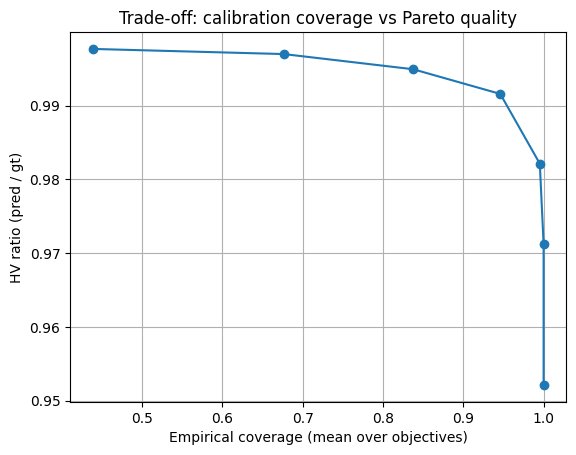

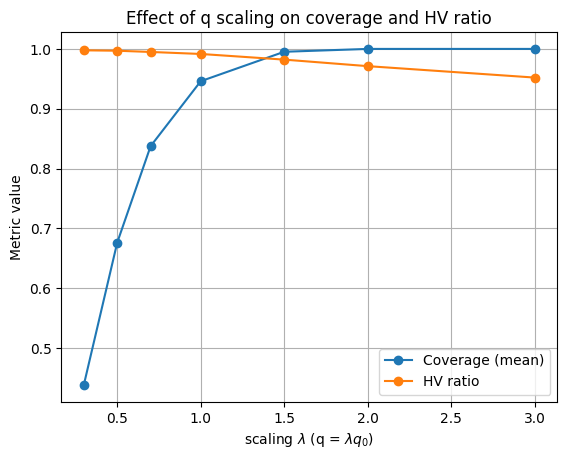

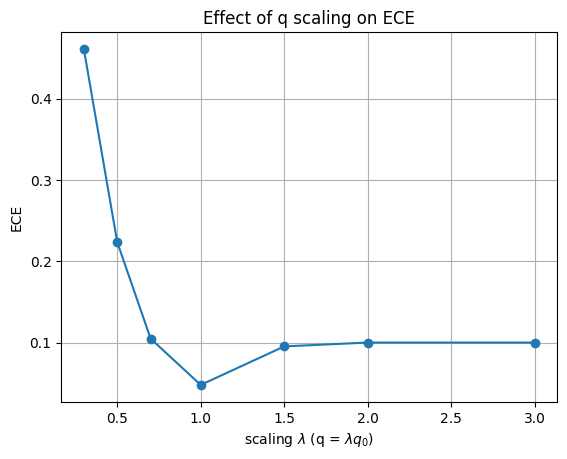

seed=0 | q_mean=1.354 | best λ=0.30 | HV*=0.998 | HV(q=1)=0.992

=== Running seed 1 ===
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.104201 | per-target RMSE=[0.1041 0.1043]
[ICM] Matern(0.5) | val-score=0.104201 | per-target RMSE=[0.1041 0.1043]
[ICM] Matern(1.5) | val-score=0.104204 | per-target RMSE=[0.1041 0.1043]
[ICM] Matern(2.5) | val-score=0.104201 | per-target RMSE=[0.1041 0.1043]
[IND:t0] RBF        | RMSE=0.137839
[IND:t0] Matern(0.5) | RMSE=0.123688
[IND:t0] Matern(1.5) | RMSE=0.116699
[IND:t0] Matern(2.5) | RMSE=0.125065
[IND:t1] RBF        | RMSE=0.134163
[IND:t1] Matern(0.5) | RMSE=0.099351
[IND:t1] Matern(1.5) | RMSE=0.126842
[IND:t1] Matern(2.5) | RMSE=0.108922
[IND] per-target best kernels -> [('Matern', 1.5), ('Matern', 0.5)]
[IND] overall val-score=0.108025 | per-target RMSE=[0.1167 0.0994]

==> Chosen family: ICM, kernel: Matern(0.5), val-score=0.104201
[finalize] refit_scope=full, N=70, scaler_mode=frozen, set_as_curren

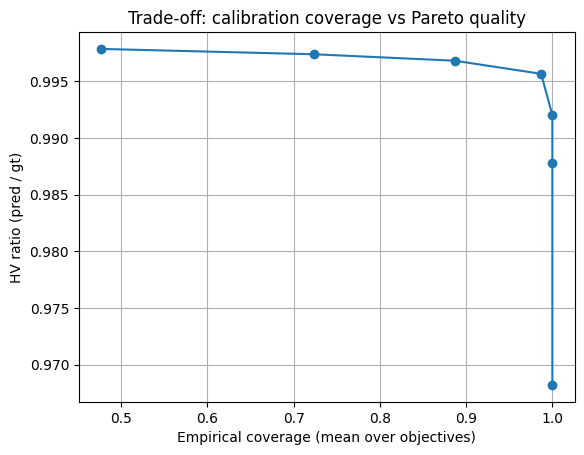

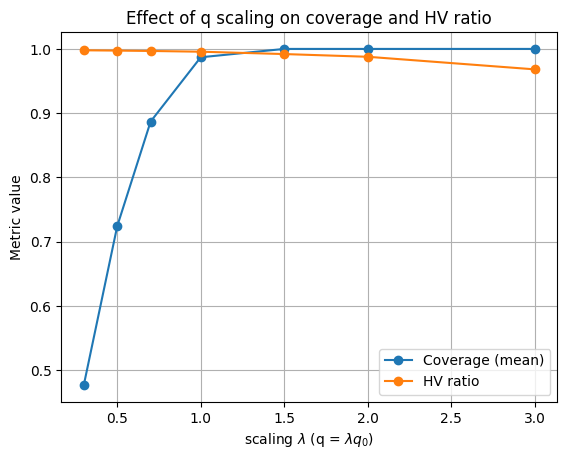

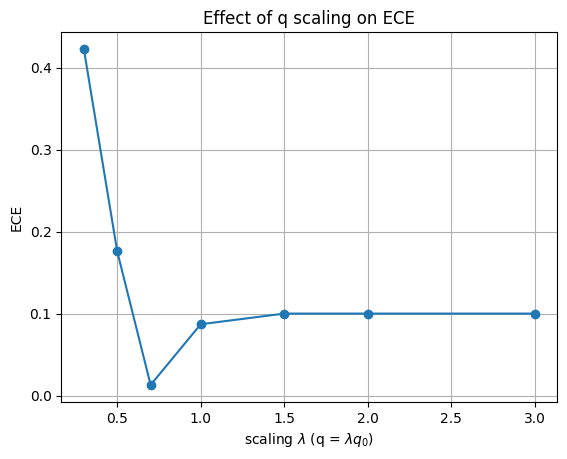

seed=1 | q_mean=1.281 | best λ=0.30 | HV*=0.998 | HV(q=1)=0.996

=== Running seed 2 ===
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.039997 | per-target RMSE=[0.0548 0.0252]
[ICM] Matern(0.5) | val-score=0.039993 | per-target RMSE=[0.0548 0.0252]
[ICM] Matern(1.5) | val-score=0.039997 | per-target RMSE=[0.0548 0.0252]
[ICM] Matern(2.5) | val-score=0.039996 | per-target RMSE=[0.0548 0.0252]
[IND:t0] RBF        | RMSE=0.061892
[IND:t0] Matern(0.5) | RMSE=0.112037
[IND:t0] Matern(1.5) | RMSE=0.045253
[IND:t0] Matern(2.5) | RMSE=0.049010
[IND:t1] RBF        | RMSE=0.032880
[IND:t1] Matern(0.5) | RMSE=0.089550
[IND:t1] Matern(1.5) | RMSE=0.035976
[IND:t1] Matern(2.5) | RMSE=0.023842
[IND] per-target best kernels -> [('Matern', 1.5), ('Matern', 2.5)]
[IND] overall val-score=0.034547 | per-target RMSE=[0.0453 0.0238]

==> Chosen family: IND, kernel: [Matern(1.5), Matern(2.5)], val-score=0.034547
[finalize] refit_scope=full, N=70, scaler_mode=frozen

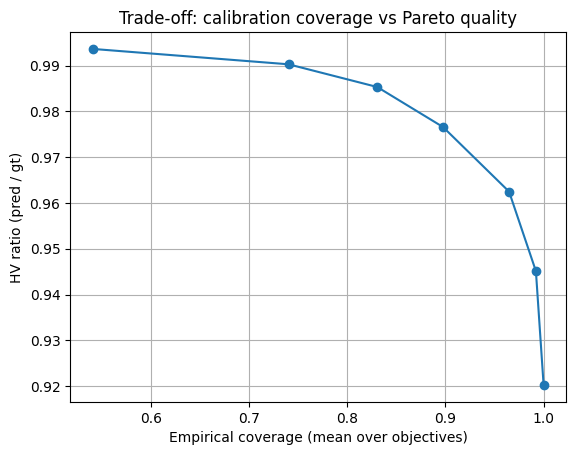

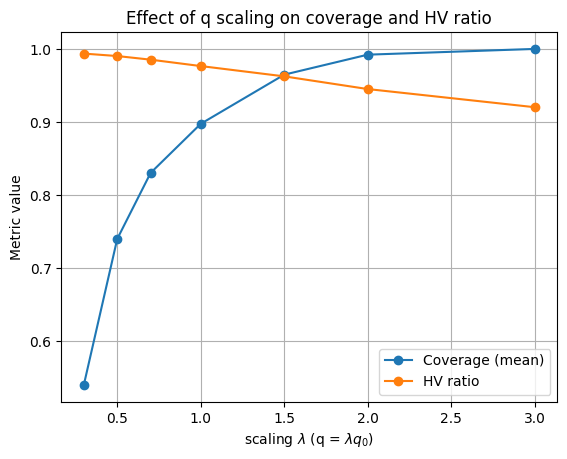

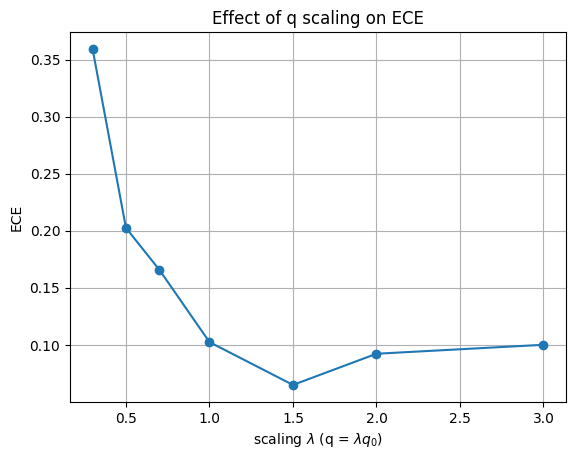

seed=2 | q_mean=1.574 | best λ=0.30 | HV*=0.994 | HV(q=1)=0.977

=== Running seed 3 ===
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.071509 | per-target RMSE=[0.065  0.0781]
[ICM] Matern(0.5) | val-score=0.071506 | per-target RMSE=[0.065  0.0781]
[ICM] Matern(1.5) | val-score=0.071510 | per-target RMSE=[0.065  0.0781]
[ICM] Matern(2.5) | val-score=0.071510 | per-target RMSE=[0.065  0.0781]
[IND:t0] RBF        | RMSE=0.067404
[IND:t0] Matern(0.5) | RMSE=0.101364
[IND:t0] Matern(1.5) | RMSE=0.073529
[IND:t0] Matern(2.5) | RMSE=0.056500
[IND:t1] RBF        | RMSE=0.097581
[IND:t1] Matern(0.5) | RMSE=0.122947
[IND:t1] Matern(1.5) | RMSE=0.099536
[IND:t1] Matern(2.5) | RMSE=0.080649
[IND] per-target best kernels -> [('Matern', 2.5), ('Matern', 2.5)]
[IND] overall val-score=0.068575 | per-target RMSE=[0.0565 0.0806]

==> Chosen family: IND, kernel: [Matern(2.5), Matern(2.5)], val-score=0.068575
[finalize] refit_scope=full, N=70, scaler_mode=frozen

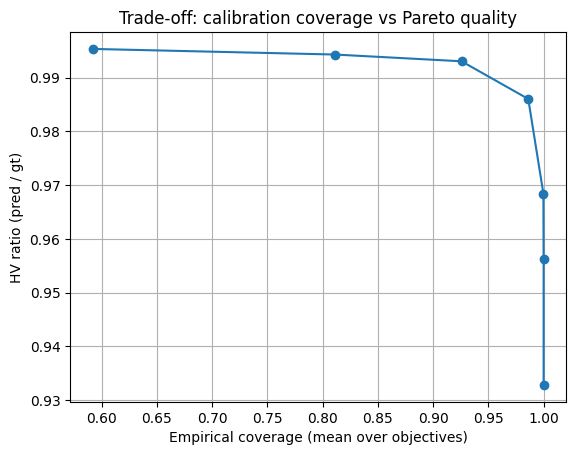

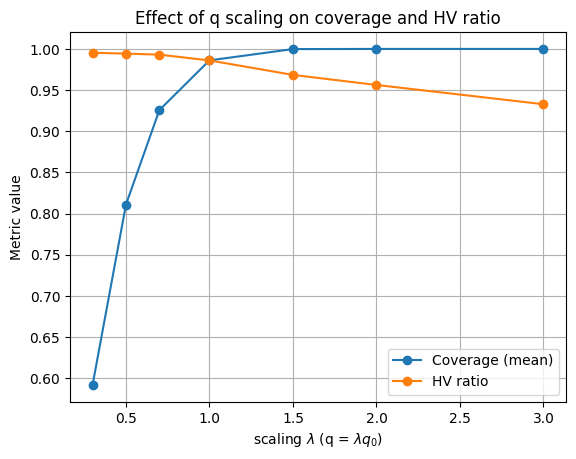

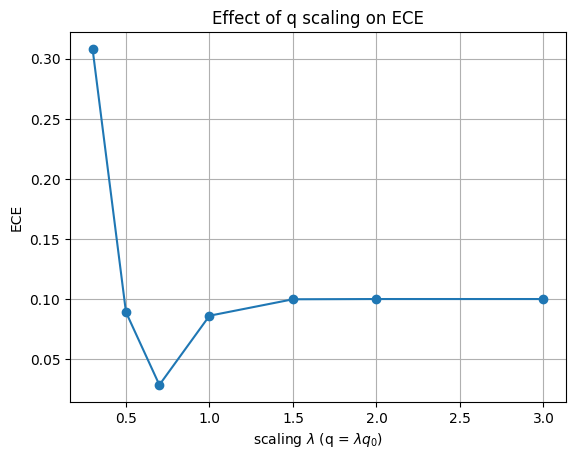

seed=3 | q_mean=1.583 | best λ=0.30 | HV*=0.995 | HV(q=1)=0.986

=== Running seed 4 ===
Split sizes -> train: 52, val: 11, test: 7 (KS_test=False)
[ICM] RBF        | val-score=0.069035 | per-target RMSE=[0.0703 0.0678]
[ICM] Matern(0.5) | val-score=0.069035 | per-target RMSE=[0.0703 0.0678]
[ICM] Matern(1.5) | val-score=0.069036 | per-target RMSE=[0.0703 0.0678]
[ICM] Matern(2.5) | val-score=0.069035 | per-target RMSE=[0.0703 0.0678]
[IND:t0] RBF        | RMSE=0.071614
[IND:t0] Matern(0.5) | RMSE=0.130113
[IND:t0] Matern(1.5) | RMSE=0.071269
[IND:t0] Matern(2.5) | RMSE=0.052661
[IND:t1] RBF        | RMSE=0.061949
[IND:t1] Matern(0.5) | RMSE=0.162500
[IND:t1] Matern(1.5) | RMSE=0.072230
[IND:t1] Matern(2.5) | RMSE=0.056508
[IND] per-target best kernels -> [('Matern', 2.5), ('Matern', 2.5)]
[IND] overall val-score=0.054585 | per-target RMSE=[0.0527 0.0565]

==> Chosen family: IND, kernel: [Matern(2.5), Matern(2.5)], val-score=0.054585
[finalize] refit_scope=full, N=70, scaler_mode=frozen

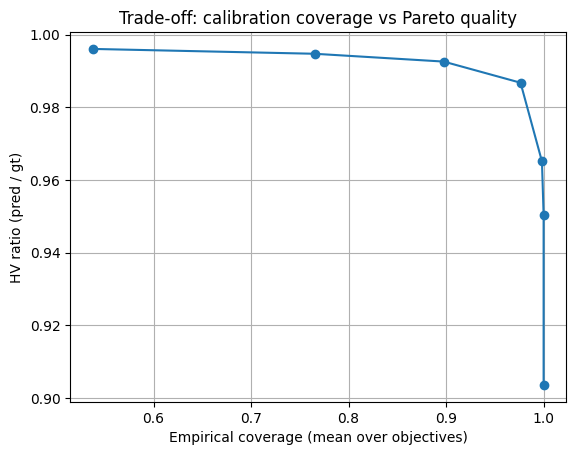

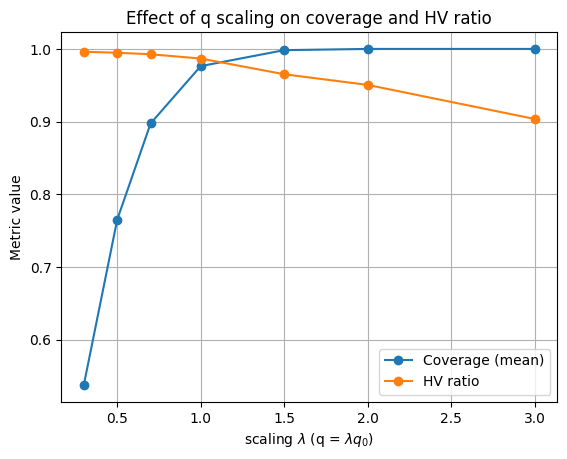

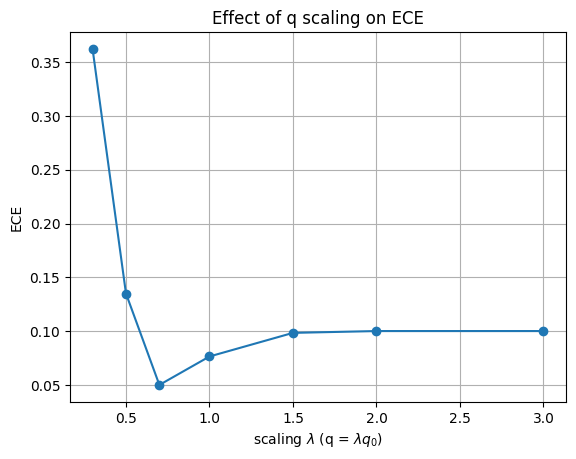

seed=4 | q_mean=1.672 | best λ=0.30 | HV*=0.996 | HV(q=1)=0.987


AttributeError: 'list' object has no attribute 'get'

In [46]:
# ------------------ Launch ------------------
seeds = [0, 1, 2, 3, 4]  # 你想跑多少就加多少

all_results = run_multi_seed_experiment(
    seeds,
    make_auto=make_auto,
    n_train=70,
    X_eval=X_eval,   Y_eval=Y_eval,
    gt_dict=gt_dict,
    pf_cfg=pf_cfg,
    alpha=0.10,
    lambdas=(0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0),  # 你可加密一点
)

summarise_multi_seed(all_results)


In [47]:
all_results1, all_records = all_results

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def _to_float_array(x):
    try:
        return np.asarray(x, dtype=float)
    except Exception:
        return np.array([float(v) if v is not None else np.nan for v in x], dtype=float)

def plot_lambda_sweep_mean_std(
    all_records,
    *,
    lambdas=None,
    metrics=("HV_ratio", "coverage_mean", "IGD", "GD", "ece", "Recall", "Hausdorff"),
    x_col="lambda",
    show_points=False,
    title_prefix="",
):
    """
    Plot mean ± std over seeds for each metric as a function of lambda.

    all_records: list of dicts, each record should include:
        - 'seed' (int)
        - 'lambda' (float)  [or 'x' from your sweep]
        - metrics columns, e.g. HV_ratio, coverage_mean, IGD, GD, ece, Recall, Hausdorff
    lambdas: optional list/tuple to enforce plotting order; otherwise inferred from data.
    show_points: if True, overlay raw per-seed points (jittered slightly).
    """
    # normalize x values
    for r in all_records:
        if x_col not in r and "x" in r:
            r[x_col] = r["x"]

    # lambda grid
    if lambdas is None:
        xs = sorted({float(r[x_col]) for r in all_records if r.get(x_col) is not None})
    else:
        xs = [float(v) for v in lambdas]

    # bucket by lambda
    by_x = {x: [] for x in xs}
    for r in all_records:
        x = r.get(x_col, None)
        if x is None:
            continue
        x = float(x)
        if x in by_x:
            by_x[x].append(r)

    # plot each metric separately
    for m in metrics:
        means, stds = [], []
        for x in xs:
            vals = [rr.get(m, np.nan) for rr in by_x.get(x, [])]
            vals = _to_float_array(vals)
            vals = vals[np.isfinite(vals)]
            means.append(float(np.mean(vals)) if vals.size else np.nan)
            stds.append(float(np.std(vals)) if vals.size else np.nan)

        plt.figure()
        plt.errorbar(xs, means, yerr=stds, marker="o", capsize=3)

        if show_points:
            rng = np.random.default_rng(0)
            for x in xs:
                vals = [rr.get(m, np.nan) for rr in by_x.get(x, [])]
                vals = _to_float_array(vals)
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                jitter = rng.normal(0.0, 0.01, size=vals.size)
                plt.scatter(np.full(vals.size, x) + jitter, vals, alpha=0.35)

        plt.xlabel("lambda")
        plt.ylabel(m)
        plt.title(f"{title_prefix}{m} vs lambda (mean ± std over seeds)")
        plt.grid(True)
        plt.show()


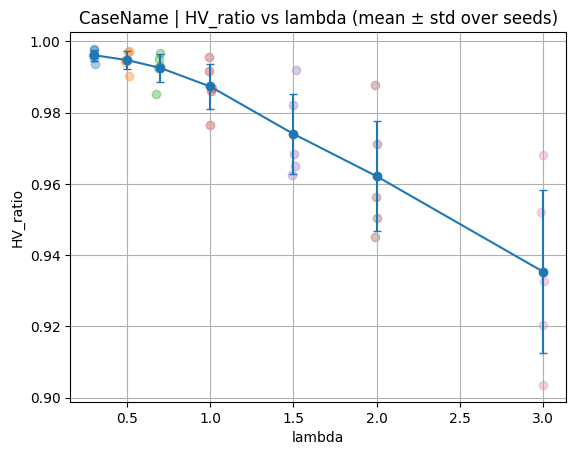

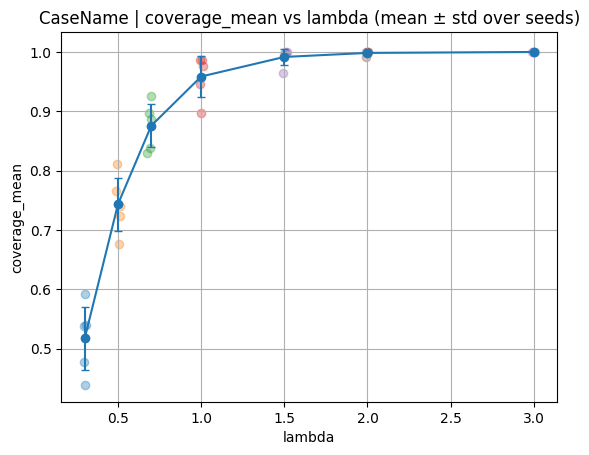

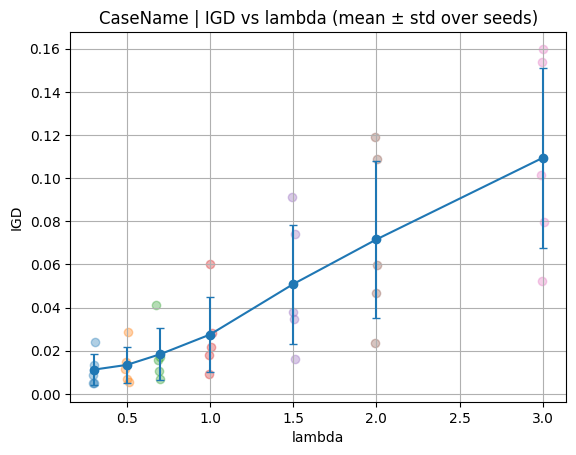

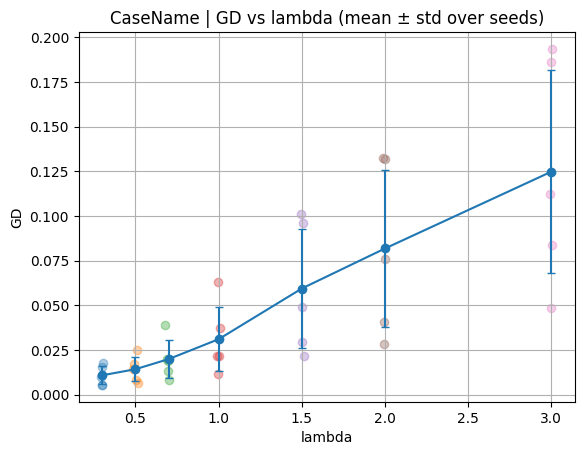

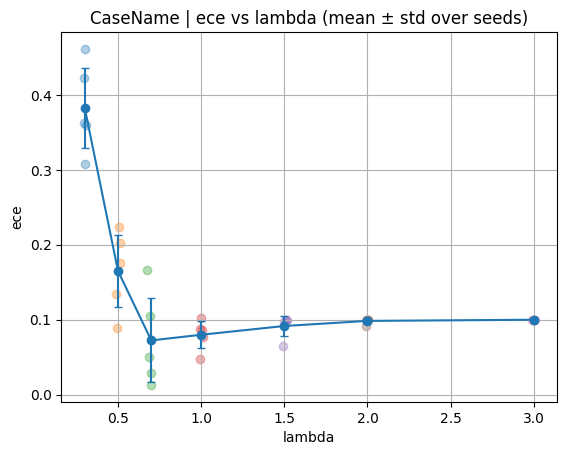

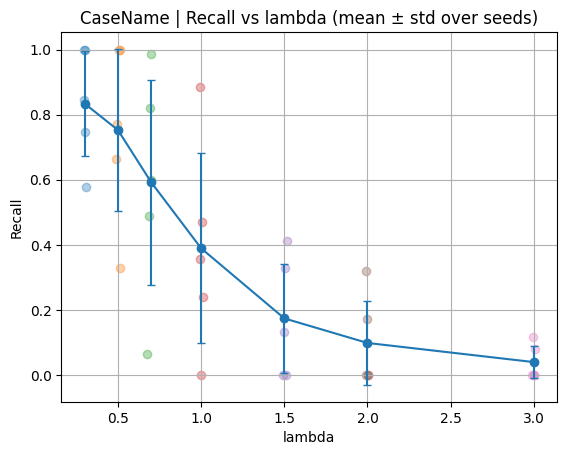

In [53]:
# seed_summaries, sweep_records = run_multi_seed_experiment(
#     seeds=[0,1,2,3,4],
#     make_auto=make_auto,
#     n_train=60,
#     X_eval=X_eval, Y_eval=Y_eval,
#     gt_dict=gt_dict,
#     pf_cfg=pf_cfg,
#     alpha=0.10,
#     lambdas=(0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0),
# )

plot_lambda_sweep_mean_std(
    all_records,
    lambdas=(0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0),
    show_points=True,  # 想只看均值曲线就改 False
    title_prefix="CaseName | ",
    metrics=("HV_ratio", "coverage_mean", "IGD", "GD", "ece", 'Recall')
)


In [51]:
def records_to_dataframe(all_records):
    import pandas as pd
    rows = []
    for r in all_records:
        rr = dict(r)
        # 把 ndarray 转成可存的标量/字符串（或拆成多列）
        if isinstance(rr.get("q_vec"), np.ndarray):
            qv = rr["q_vec"]
            rr["q_mean"] = float(np.mean(qv))
            rr["q_min"]  = float(np.min(qv))
            rr["q_max"]  = float(np.max(qv))
            for j in range(len(qv)):
                rr[f"q_{j}"] = float(qv[j])
            rr.pop("q_vec", None)
        if isinstance(rr.get("coverage_vec"), np.ndarray):
            cv = rr["coverage_vec"]
            for j in range(len(cv)):
                rr[f"cov_{j}"] = float(cv[j])
            rr.pop("coverage_vec", None)
        # pareto_X/pareto_Y 如果很大就别放进 df（太重）
        rr.pop("pareto_X", None)
        rr.pop("pareto_Y", None)
        rows.append(rr)
    return pd.DataFrame(rows)
df_sweep = records_to_dataframe(all_records)
df_sweep.to_csv("all_records_lambda_sweep.csv", index=False)
print("Saved to all_records_lambda_sweep.csv")


Saved to all_records_lambda_sweep.csv


In [52]:
import pandas as pd
df = pd.read_csv("all_records_lambda_sweep.csv")
df.head()

,i,x,q_mean,q_min,q_max,coverage_mean,ece,HV_ratio,HV_pred,HV_gt,...,n_pareto,seed,lambda,q_base_mean,q_base_min,q_base_max,q_0,q_1,cov_0,cov_1
0,0,0.3,0.406343,0.357756,0.454930,0.43865,0.46135,0.997678,3.755813,3.764555,...,256,0,0.3,1.354477,1.19252,1.516434,0.357756,0.454930,0.3344,0.5429
1,1,0.5,0.677239,0.596260,0.758217,0.67640,0.22360,0.996982,3.753193,3.764555,...,256,0,0.5,1.354477,1.19252,1.516434,0.596260,0.758217,0.5447,0.8081
2,2,0.7,0.948134,0.834764,1.061504,0.83760,0.10480,0.994924,3.745445,3.764555,...,256,0,0.7,1.354477,1.19252,1.516434,0.834764,1.061504,0.7328,0.9424
3,3,1.0,1.354477,1.192520,1.516434,0.94605,0.04785,0.991580,3.732856,3.764555,...,256,0,1.0,1.354477,1.19252,1.516434,1.192520,1.516434,0.8982,0.9939
4,4,1.5,2.031716,1.788780,2.274651,0.99525,0.09525,0.982130,3.697281,3.764555,...,256,0,1.5,1.354477,1.19252,1.516434,1.788780,2.274651,0.9905,1.0000


def coverage_vs_HV